# Trabajo Practico Integrador — Entrega 3
## Ciencia de Datos 2026 | UTN FRC | 5K4 | Grupo 15

---

### Descripcion

Valida la **Hipotesis H1** probando multiples familias de algoritmos de Machine Learning y comparando el mejor de cada una.

> **H1:** *"Existe una correlacion positiva y cuantificable entre la frecuencia cardiaca media del sujeto y el nivel de intensidad de la actividad fisica clasificada (baja, moderada y vigorosa)."*

**Estructura:**
| Sec | Contenido | Target |
|-----|-----------|--------|
| 0 | Setup | — |
| 1 | Exploracion + Division por sujetos + **H1** (RegLin + LogReg) | `nivel_intensidad` |
| 2 | Clasificadores Lineales (LogReg, LinearSVC) | `actividad_id` (12 clases) |
| 3 | Arboles de Decision (DT, RF, ExtraTrees) | `actividad_id` |
| 4 | XGBoost | `actividad_id` |
| 5 | Otros Clasificadores (K-NN, Naive Bayes) | `actividad_id` |
| 6 | Comparacion Global + FP/FN + conclusion H1 | — |
| 7 | Demostracion en Vivo | — |
| 8 | Conclusiones | — |

**Division de datos:** sujetos 102, 106, 108 para prueba (~35%). Resto para entrenamiento.

---

| Rol | Nombre | Legajo |
|-----|--------|--------|
| Product Owner | Franco Recalde | 94661 |
| Scrum Master | Emilio Sadir | 96622 |
| dev | Rodriguez, Joaquin Ignacio | 85406 |
| dev | Noto, Claudia Carina | 95215 |
| dev | Monteros, Leandro Ignacio | 90258 |
| dev | Ferraro, Ayelen | 99149 |
| dev | Chiaro, Tiziano | 90043 |
| dev | Bailey, Julian Eduardo | 96032 |

---
# Seccion 0 — Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, r2_score,
    mean_squared_error, mean_absolute_error
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print('Librerias cargadas.')

Librerias cargadas.


In [10]:
try:
    import google.colab
    IN_COLAB = True
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'xgboost'], check=True)
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/TP_CD')
else:
    BASE_PATH = Path('..').resolve()

DATA_PATH    = BASE_PATH / 'data' / 'processed' / 'pamap2_limpio.csv'
FIGURES_PATH = BASE_PATH / 'reports' / 'entrega_3' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')

Entorno: Local


In [11]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas | Nulos: {df.isnull().sum().sum()}')
total = len(df)
filas_x_sujeto = df.groupby('sujeto_id').size().rename('filas')
display(pd.concat([filas_x_sujeto, (filas_x_sujeto/total*100).round(1).rename('pct%')], axis=1))

Shape: 109,812 filas x 43 columnas | Nulos: 0


,filas,pct%
sujeto_id,,
101,14057,12.8000
102,13039,11.9000
103,10005,9.1000
104,13967,12.7000
105,15586,14.2000
106,15009,13.7000
107,17346,15.8000
108,10390,9.5000
109,413,0.4000


### Paso 0.3 — Constantes, feature engineering y funciones auxiliares

In [12]:
# --- Nombres de actividades en espanol ---
ACTIVIDAD_MAP = {
    1: 'acostado',        2: 'sentado',          3: 'de pie',
    4: 'caminata',        5: 'corriendo',         6: 'ciclismo',
    7: 'marcha nordica',  12: 'subir escaleras', 13: 'bajar escaleras',
    16: 'aspirar',        17: 'planchar',          24: 'saltar soga'
}

# Ciclismo = vigoroso (alta demanda cardiovascular)
INTENSIDAD_MAP = {
    1: 0, 2: 0, 3: 0,       # baja:     acostado, sentado, de pie
    4: 1, 16: 1, 17: 1,     # moderada: caminata, aspirar, planchar
    5: 2, 6: 2, 7: 2,       # vigorosa: corriendo, ciclismo, marcha nordica
    12: 2, 13: 2, 24: 2,    # vigorosa: subir/bajar escaleras, saltar soga
}
INTENSIDAD_NOMBRES = {0: 'baja', 1: 'moderada', 2: 'vigorosa'}
INTENSIDAD_COLORES = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
INTENSIDAD_ORDEN   = ['baja', 'moderada', 'vigorosa']

df['nivel_intensidad'] = df['actividad_id'].map(INTENSIDAD_MAP)

# Magnitudes invariantes a la orientacion del sensor
for parte in ['mano', 'pecho', 'tobillo']:
    for sensor in ['acel1', 'acel2']:
        cols = [f'{parte}_{sensor}_{ax}' for ax in ['x', 'y', 'z']]
        if all(c in df.columns for c in cols):
            df[f'{parte}_{sensor}_mag'] = np.sqrt((df[cols] ** 2).sum(axis=1))
    cols_g = [f'{parte}_giro_{ax}' for ax in ['x', 'y', 'z']]
    if all(c in df.columns for c in cols_g):
        df[f'{parte}_giro_mag'] = np.sqrt((df[cols_g] ** 2).sum(axis=1))

SENSOR_COLS = [c for c in df.columns
               if c not in ['tiempo', 'actividad_id', 'sujeto_id', 'nivel_intensidad']]
mag_cols = [c for c in SENSOR_COLS if c.endswith('_mag')]

print(f'SENSOR_COLS: {len(SENSOR_COLS)} features ({len(mag_cols)} magnitudes)')
print()
for k in [0, 1, 2]:
    n    = (df['nivel_intensidad'] == k).sum()
    acts = [ACTIVIDAD_MAP[a] for a, v in INTENSIDAD_MAP.items() if v == k]
    print(f'  {INTENSIDAD_NOMBRES[k]:10s} ({k}): {n:,} filas  <- {acts}')

# Dict global donde cada seccion almacena sus resultados de clasificacion
todos_clasificadores = {}


def plot_cm(y_true, y_pred, labels, label_names, title, filename=None, figsize=(12, 10)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.4, cbar=False)
    ax.set_xlabel('Predicho', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    if filename:
        plt.savefig(FIGURES_PATH / filename, dpi=100, bbox_inches='tight')
    plt.show()


def analizar_fp_fn(nombre_modelo, y_pred):
    """Genera tabla y grafico de FP/FN. Usa globals: y_test_act, h_labels, ACTIVIDAD_MAP."""
    y_true = y_test_act.values
    rows = []
    for act_id in h_labels:
        mask_r = (y_true == act_id);  mask_p = (y_pred == act_id)
        tp = int(np.sum(mask_r & mask_p));    fp = int(np.sum(~mask_r & mask_p))
        fn = int(np.sum(mask_r & ~mask_p));   tn = int(np.sum(~mask_r & ~mask_p))
        prec   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        rows.append({'Actividad': ACTIVIDAD_MAP.get(act_id, str(act_id)),
                     'Total real': int(mask_r.sum()),
                     'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                     'Precision': round(prec, 3), 'Recall': round(recall, 3)})
    df_fpfn = pd.DataFrame(rows).set_index('Actividad')
    display(df_fpfn.style
            .format({'Precision': '{:.3f}', 'Recall': '{:.3f}'})
            .background_gradient(subset=['FP', 'FN'], cmap='Reds')
            .set_caption(f'FP y FN — {nombre_modelo}'))

    fig, ax = plt.subplots(figsize=(13, 6))
    x, w = np.arange(len(df_fpfn)), 0.35
    b1 = ax.bar(x - w/2, df_fpfn['FP'], w, label='Falsos Positivos', color='#FF7043', alpha=0.87)
    b2 = ax.bar(x + w/2, df_fpfn['FN'], w, label='Falsos Negativos', color='#1565C0', alpha=0.87)
    ax.set_xticks(x);  ax.set_xticklabels(df_fpfn.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Cantidad de registros')
    ax.set_title(f'Falsos Positivos y Negativos — {nombre_modelo}')
    ax.legend(fontsize=10)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                    str(int(h)), ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'fp_fn_mejor_global.png', dpi=100, bbox_inches='tight')
    plt.show()
    return df_fpfn


def evaluar_clasificador(nombre, modelo, y_pred):
    """Calcula metricas de clasificacion y almacena en todos_clasificadores."""
    y_pred_enc = le.transform(y_pred)
    acc_train  = accuracy_score(y_train_act, modelo.predict(X_train))
    acc_test   = accuracy_score(y_test_act,  y_pred)
    f1_val     = f1_score(y_test_act, y_pred, average='macro', zero_division=0)
    r2_val     = r2_score(y_test_enc, y_pred_enc)
    todos_clasificadores[nombre] = {
        'modelo': modelo, 'y_pred': y_pred,
        'acc_train': acc_train, 'acc_test': acc_test,
        'f1_macro': f1_val, 'R2': r2_val
    }
    print(f'  Exactitud entrena: {acc_train:.4f}')
    print(f'  Exactitud prueba:  {acc_test:.4f}')
    print(f'  F1 macro:          {f1_val:.4f}')
    print(f'  R2 (etiq. 0-11):   {r2_val:.4f}   {"OK >= 0.6" if r2_val >= 0.6 else "bajo"}')
    return todos_clasificadores[nombre]

SENSOR_COLS: 49 features (9 magnitudes)

  baja       (0): 27,527 filas  <- ['acostado', 'sentado', 'de pie']
  moderada   (1): 38,902 filas  <- ['caminata', 'aspirar', 'planchar']
  vigorosa   (2): 43,383 filas  <- ['corriendo', 'ciclismo', 'marcha nordica', 'subir escaleras', 'bajar escaleras', 'saltar soga']


---
# Seccion 1 — Exploracion y Division por Sujetos

**Mapeo de intensidad:**

| Nivel | Cod | Actividades |
|-------|-----|-------------|
| Baja | 0 | acostado, sentado, de pie |
| Moderada | 1 | caminata, aspirar, planchar |
| Vigorosa | 2 | corriendo, ciclismo, marcha nordica, subir/bajar escaleras, saltar soga |

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14848\1554710009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='nivel_nombre', y='frecuencia_cardiaca',


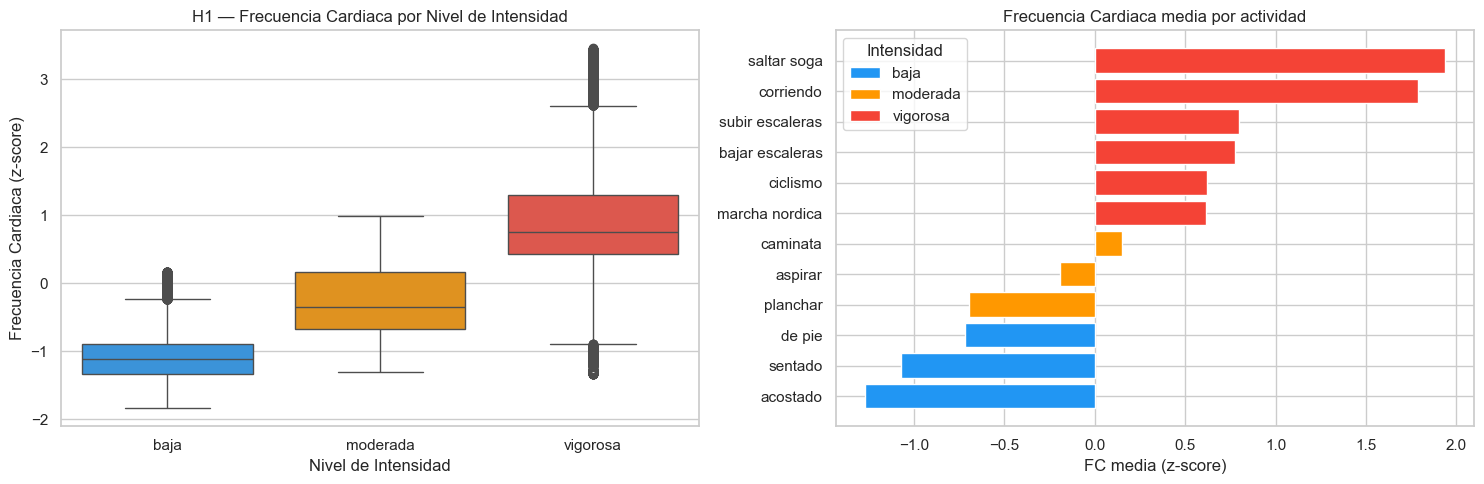

,count,mean,std,min,25%,50%,75%,max
nivel_intensidad,,,,,,,,
baja,27527.0000,-1.0724,0.3948,-1.8397,-1.3289,-1.1130,-0.8911,0.1669
moderada,38902.0000,-0.2578,0.4973,-1.3107,-0.6722,-0.3438,0.1669,0.9795
vigorosa,43383.0000,0.9116,0.7683,-1.3289,0.4223,0.7507,1.2979,3.4505


In [13]:
df_plot = df.copy()
df_plot['nivel_nombre'] = df_plot['nivel_intensidad'].map(INTENSIDAD_NOMBRES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df_plot, x='nivel_nombre', y='frecuencia_cardiaca',
            order=INTENSIDAD_ORDEN,
            palette=[INTENSIDAD_COLORES[k] for k in [0, 1, 2]], ax=axes[0])
axes[0].set_title('H1 — Frecuencia Cardiaca por Nivel de Intensidad', fontsize=12)
axes[0].set_xlabel('Nivel de Intensidad')
axes[0].set_ylabel('Frecuencia Cardiaca (z-score)')

fc_media   = df.groupby('actividad_id')['frecuencia_cardiaca'].mean().sort_values()
bar_colors = [INTENSIDAD_COLORES[INTENSIDAD_MAP[a]] for a in fc_media.index]
act_names  = [ACTIVIDAD_MAP.get(a, str(a)) for a in fc_media.index]
axes[1].barh(act_names, fc_media.values, color=bar_colors)
axes[1].set_title('Frecuencia Cardiaca media por actividad', fontsize=12)
axes[1].set_xlabel('FC media (z-score)')
axes[1].legend(handles=[mpatches.Patch(facecolor=INTENSIDAD_COLORES[k],
               label=INTENSIDAD_NOMBRES[k]) for k in [0, 1, 2]], title='Intensidad')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'h1_boxplot_intensidad.png', dpi=100, bbox_inches='tight')
plt.show()
display(df.groupby('nivel_intensidad')['frecuencia_cardiaca'].describe().rename(index=INTENSIDAD_NOMBRES))

### 1.2 — Division por Sujetos

Los **sujetos 102, 106, 108** conforman el conjunto de prueba (~35.0%, 38.438 filas).
El resto —incluido el sujeto 109— forma el conjunto de entrenamiento.

> **Por que no split aleatorio?** Si filas del mismo sujeto estan en train y test, el modelo memoriza
> los patrones de movimiento especificos de esa persona (cadencia, FC basal) y obtiene una performance
> artificialmente alta. Con split por sujetos se mide la generalizacion real a personas nuevas.

| Conjunto | Sujetos | Filas | % |
|----------|---------|-------|---|
| Entrenamiento | 101, 103, 104, 105, 107, 109 | ~71.374 | ~65.0% |
| Prueba | 102, 106, 108 | ~38.438 | ~35.0% |

In [14]:
SUJETOS_PRUEBA = [102, 106, 108]   # ~35% del dataset
# Sujeto 109 incluido en entrenamiento (solo 413 filas pero datos validos)

df_train = df[~df['sujeto_id'].isin(SUJETOS_PRUEBA)].copy()
df_test  = df[df['sujeto_id'].isin(SUJETOS_PRUEBA)].copy()

X_train = df_train[SENSOR_COLS]
X_test  = df_test[SENSOR_COLS]
y_train_act = df_train['actividad_id']
y_test_act  = df_test['actividad_id']
y_train_int = df_train['nivel_intensidad']
y_test_int  = df_test['nivel_intensidad']

# LabelEncoder: IDs [1,2,3,4,5,6,7,12,13,16,17,24] -> [0..11]
# Necesario para R2 en clasificacion: evita que la diferencia entre ID 1 y ID 24
# infle artificialmente los residuos y hunda el R2.
h_labels      = sorted(y_test_act.unique())
h_label_names = [ACTIVIDAD_MAP.get(a, str(a)) for a in h_labels]
le = LabelEncoder().fit(h_labels)

print(f'Entrenamiento: {len(X_train):,} filas ({len(X_train)/len(df)*100:.1f}%) sujetos: {sorted(df_train["sujeto_id"].unique())}')
print(f'Prueba:        {len(X_test):,}  filas ({len(X_test)/len(df)*100:.1f}%) sujetos: {SUJETOS_PRUEBA}')
print(f'Features:      {X_train.shape[1]} (incluye {len(mag_cols)} magnitudes)')
y_test_enc = le.transform(y_test_act)   # labels 0-11 para R2 en clasificacion

Entrenamiento: 71,374 filas (65.0%) sujetos: [np.int64(101), np.int64(103), np.int64(104), np.int64(105), np.int64(107), np.int64(109)]
Prueba:        38,438  filas (35.0%) sujetos: [102, 106, 108]
Features:      49 (incluye 9 magnitudes)


### Por que baja la precision con split por sujetos?

Con split aleatorio (65/35), el mismo sujeto aparece en train y test. El modelo **memoriza** los patrones
individuales de cada persona y puede superar el 90%. Con split por sujetos debe **generalizar** a personas
nuevas: la caida tipica en PAMAP2 es del ~90% → ~70-85%. Esa es la performance **real** del sistema.

**Estrategias para mejorar la generalizacion (ya aplicadas):**
1. **Magnitudes de aceleracion** — invariantes a la orientacion del sensor, mas consistentes entre sujetos
2. **Extra Trees** — cortes de split aleatorios generan mayor diversidad entre arboles → menos overfitting

**Nota sobre R2 en clasificacion:** los IDs de actividad son no-consecutivos (1,2,3,4,5,6,7,**12,13,16,17,24**).
Si el modelo predice 7 en lugar de 24, el residuo es 17 — mucho mayor que si los IDs fueran [0..11].
Esto hunde artificialmente el R2. Se usa `LabelEncoder` para mapear a [0..11] antes de calcular R2.

### 1.3 — Analisis de Hipotesis H1

**H1:** *Existe una correlacion positiva entre la frecuencia cardiaca media y el nivel de intensidad de la actividad fisica.*

Para confirmar o refutar H1 se entrenan dos modelos sobre `nivel_intensidad` (0=baja, 1=moderada, 2=vigorosa):

| Modelo | Tipo de prediccion | Metricas clave |
|--------|-------------------|----------------|
| **Regresion Lineal** | Valor continuo en R; se redondea a {0,1,2} | R² (bondad de ajuste) + r de Pearson (direccion de la correlacion) |
| **Regresion Logistica** | Probabilidades por clase; esperanza = sum(k*P(k)) en [0,2] | Accuracy + F1 macro (calidad de clasificacion discreta) |

**Diferencia conceptual:**
- **LinReg** minimiza el error cuadratico medio buscando una relacion lineal directa entre sensores e intensidad. Sus coeficientes son interpretables: un coeficiente positivo en `frecuencia_cardiaca` significa que a mayor FC, mayor intensidad predicha.
- **LogReg** aprende fronteras de decision probabilisticas entre las tres clases. No asume linealidad en los valores, sino en los log-odds. Se usa el valor esperado de la distribucion predicha como salida continua comparable con LinReg.

**Criterios de confirmacion de H1:**
- R² ≥ 0.6 en al menos un modelo
- r de Pearson > 0 (correlacion positiva FC ↔ intensidad)
- p-valor < 0.05 (estadisticamente significativo)

In [15]:
# --- 1.3 Analisis de Hipotesis H1 ---
resultados_reg = {}
idx_fc = list(SENSOR_COLS).index('frecuencia_cardiaca')

modelos_h1 = {
    'Regresion Lineal': LinearRegression(),
    'Reg. Logistica':   LogisticRegression(solver='lbfgs', max_iter=1000),
}

for nombre, modelo in modelos_h1.items():
    modelo.fit(X_train, y_train_int)

    if hasattr(modelo, 'predict_proba'):
        proba      = modelo.predict_proba(X_test)
        y_pred_raw = proba @ np.array([0.0, 1.0, 2.0])
    else:
        y_pred_raw = modelo.predict(X_test)

    r2_val   = r2_score(y_test_int, y_pred_raw)
    rmse_val = float((mean_squared_error(y_test_int, y_pred_raw)) ** 0.5)
    mae_val  = mean_absolute_error(y_test_int, y_pred_raw)
    r_val, p_val = stats.pearsonr(y_test_int, y_pred_raw)

    if modelo.coef_.ndim == 1:
        coef_fc = float(modelo.coef_[idx_fc])
    else:
        coef_fc = float(modelo.coef_[2, idx_fc] - modelo.coef_[0, idx_fc])

    resultados_reg[nombre] = {
        'modelo': modelo, 'y_pred_raw': y_pred_raw,
        'R2': r2_val, 'RMSE': rmse_val, 'MAE': mae_val,
        'r_Pearson': r_val, 'p_valor': p_val, 'coef_fc': coef_fc,
    }
    print(f'--- {nombre} ---')
    print(f'  R2:           {r2_val:.4f}   {"OK >= 0.6" if r2_val >= 0.6 else "BAJO < 0.6"}')
    print(f'  RMSE:         {rmse_val:.4f}')
    print(f'  MAE:          {mae_val:.4f}')
    print(f'  r de Pearson: {r_val:.4f}   {"positivo H1 OK" if r_val > 0 else "negativo"}')
    print(f'  p-valor:      {p_val:.2e}   {"significativo" if p_val < 0.05 else "NO significativo"}')
    print(f'  Coef. FC:     {coef_fc:+.4f}   {"H1 OK" if coef_fc > 0 else "negativo"}')
    print()

mejor_h1_r2 = max(r['R2'] for r in resultados_reg.values())
h1_ok = all(r['R2'] >= 0.6 and r['r_Pearson'] > 0 and r['p_valor'] < 0.05
            for r in resultados_reg.values())
print(f'>>> H1: {"CONFIRMADA" if h1_ok else "PARCIALMENTE CONFIRMADA (ver Sec 6.3)"}  '
      f'-- mejor R2={mejor_h1_r2:.4f}')

--- Regresion Lineal ---
  R2:           0.6111   OK >= 0.6
  RMSE:         0.4553
  MAE:          0.3761
  r de Pearson: 0.7925   positivo H1 OK
  p-valor:      0.00e+00   significativo
  Coef. FC:     +0.4789   H1 OK

--- Reg. Logistica ---
  R2:           0.7231   OK >= 0.6
  RMSE:         0.3842
  MAE:          0.2043
  r de Pearson: 0.8519   positivo H1 OK
  p-valor:      0.00e+00   significativo
  Coef. FC:     +9.5382   H1 OK

>>> H1: CONFIRMADA  -- mejor R2=0.7231


---
# Seccion 2 — Clasificadores Lineales

**Target:** `actividad_id` (12 clases) — misma tarea que Secciones 3, 4 y 5.

Los clasificadores lineales buscan **hiperplanos de decision** en el espacio de features. Son los modelos mas simples de clasificacion multiclase y sirven como linea base para comparar con metodos mas complejos.

| Modelo | Descripcion | Parametro clave |
|--------|-------------|------------------|
| **Regresion Logistica** | Estima P(clase\|x) via softmax; predice la clase de mayor probabilidad | `C` — inverso de regularizacion L2 (mayor C = menos regularizacion) |
| **LinearSVC** | Maximiza el margen entre clases con un hiperplano lineal; mas rapido que SVC(rbf) en datasets grandes | `C` — penaliza las violaciones de margen (mayor C = margen mas estricto) |

**Ventajas:** rapidos, interpretables, bajo consumo de memoria.  
**Limitaciones:** asumen separabilidad lineal aproximada; pueden no capturar relaciones no lineales entre sensores y actividades.

In [16]:
print('Entrenando clasificadores lineales...')

modelos_lineales_nombres = ['Reg. Logistica', 'LinearSVC']
modelos_lineales = {
    'Reg. Logistica': LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                                         multi_class='multinomial'),
    'LinearSVC':      LinearSVC(C=1.0, class_weight='balanced',
                                max_iter=2000, random_state=42),
}

for nombre, modelo in modelos_lineales.items():
    modelo.fit(X_train, y_train_act)
    y_pred = modelo.predict(X_test)
    print(f'\n--- {nombre} ---')
    evaluar_clasificador(nombre, modelo, y_pred)

mejor_lineal_nombre = max(modelos_lineales_nombres,
                          key=lambda n: todos_clasificadores[n]['f1_macro'])
print(f'\n>>> Mejor clasificador lineal: {mejor_lineal_nombre}  '
      f'(F1={todos_clasificadores[mejor_lineal_nombre]["f1_macro"]:.4f})')


Entrenando clasificadores lineales...


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Reg. Logistica ---
  Exactitud entrena: 0.9421
  Exactitud prueba:  0.6745
  F1 macro:          0.6077
  R2 (etiq. 0-11):   0.2971   bajo

--- LinearSVC ---
  Exactitud entrena: 0.9195
  Exactitud prueba:  0.6865
  F1 macro:          0.6482
  R2 (etiq. 0-11):   0.2609   bajo

>>> Mejor clasificador lineal: LinearSVC  (F1=0.6482)


### 2.1 — Comparacion de metricas (clasificadores lineales)

,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11),R2 >= 0.6
Modelo,,,,,
Reg. Logistica,0.9421,0.6745,0.6077,0.2971,bajo
LinearSVC,0.9195,0.6865,0.6482,0.2609,bajo


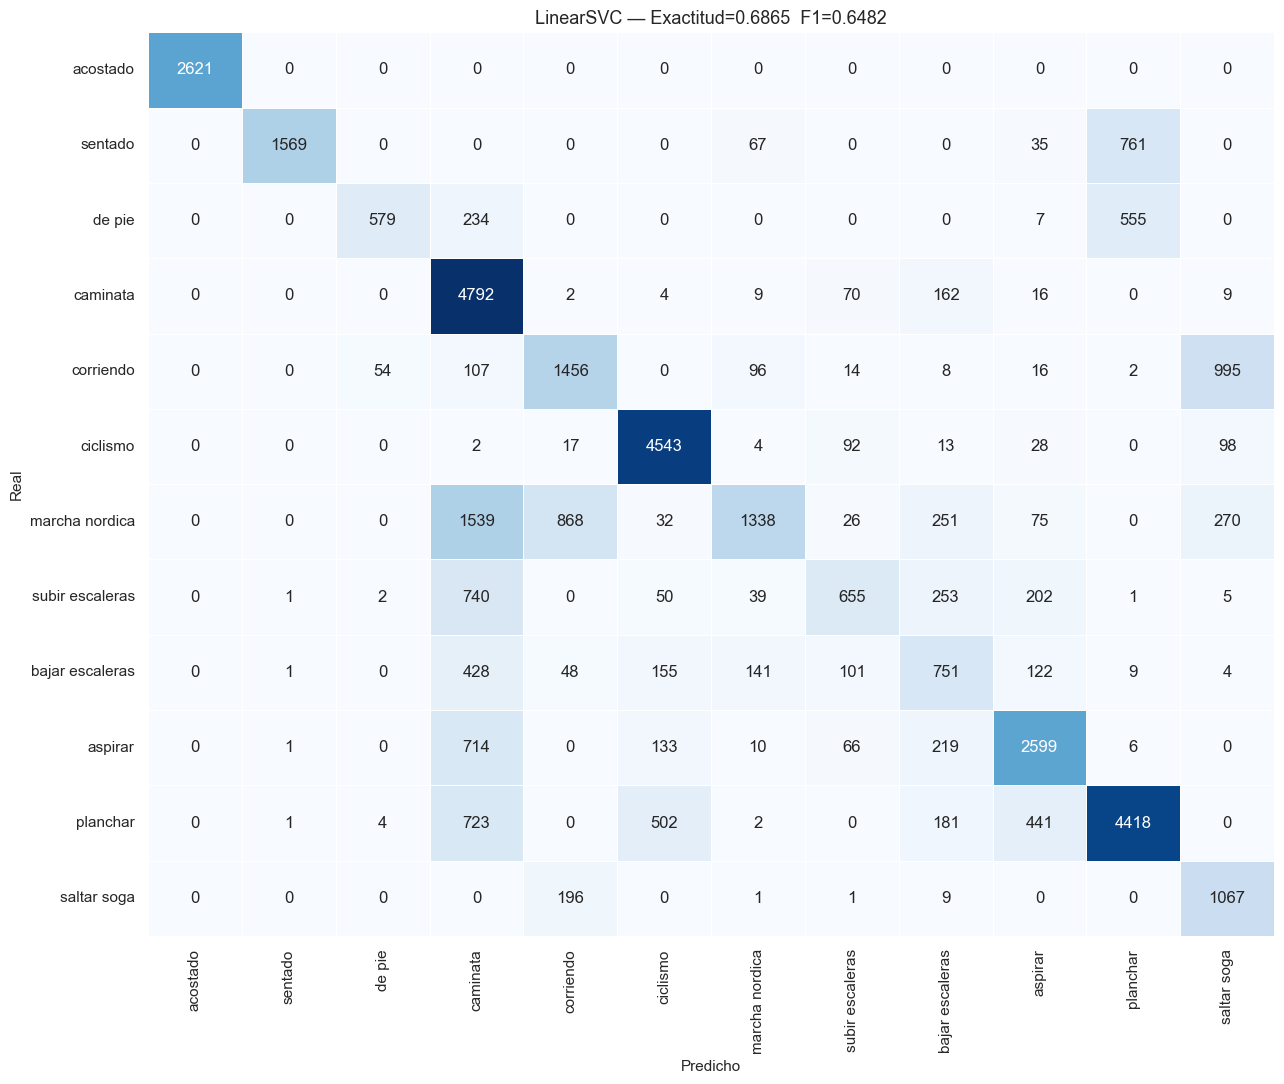

In [17]:
tabla_lineales = pd.DataFrame([
    {'Modelo': n,
     'Exactit. entrena': round(todos_clasificadores[n]['acc_train'], 4),
     'Exactit. prueba':  round(todos_clasificadores[n]['acc_test'],  4),
     'F1 macro':         round(todos_clasificadores[n]['f1_macro'],  4),
     'R2 (0-11)':        round(todos_clasificadores[n]['R2'],         4),
     'R2 >= 0.6':        'OK' if todos_clasificadores[n]['R2'] >= 0.6 else 'bajo'}
    for n in modelos_lineales_nombres
]).set_index('Modelo')

display(tabla_lineales.style
        .format({'Exactit. entrena':'{:.4f}','Exactit. prueba':'{:.4f}',
                 'F1 macro':'{:.4f}','R2 (0-11)':'{:.4f}'})
        .highlight_max(subset=['Exactit. prueba','F1 macro','R2 (0-11)'], axis=0, color='#d4f0d4')
        .set_caption('Clasificadores Lineales — target: actividad_id (12 clases)'))

plot_cm(
    y_test_act, todos_clasificadores[mejor_lineal_nombre]['y_pred'],
    h_labels, h_label_names,
    f'{mejor_lineal_nombre} — Exactitud={todos_clasificadores[mejor_lineal_nombre]["acc_test"]:.4f}  '
    f'F1={todos_clasificadores[mejor_lineal_nombre]["f1_macro"]:.4f}',
    'lineales_cm.png', figsize=(13, 11)
)


### 2.2 — Comparacion de hiperparametros (clasificadores lineales)

Se reentrena **Reg. Logistica** y **LinearSVC** variando el parametro de regularizacion `C`.
Un `C` mas alto reduce la regularizacion (modelo mas flexible); un `C` mas bajo la aumenta (modelo mas conservador).

| Familia | Configuraciones | Metrica objetivo |
|---------|----------------|------------------|
| Reg. Logistica | C = 0.01 / 0.1 / 1.0 / 10.0 | F1 macro (clasificacion 12 clases) |
| LinearSVC | C = 0.01 / 0.1 / 1.0 / 10.0 | F1 macro (clasificacion 12 clases) |

In [18]:
import time

configs_lineales = [
    ('Reg. Logistica', 'C=0.01',  LogisticRegression(C=0.01,  solver='lbfgs', max_iter=1000, multi_class='multinomial')),
    ('Reg. Logistica', 'C=0.1',   LogisticRegression(C=0.1,   solver='lbfgs', max_iter=1000, multi_class='multinomial')),
    ('Reg. Logistica', 'C=1.0',   LogisticRegression(C=1.0,   solver='lbfgs', max_iter=1000, multi_class='multinomial')),
    ('Reg. Logistica', 'C=10.0',  LogisticRegression(C=10.0,  solver='lbfgs', max_iter=1000, multi_class='multinomial')),
    ('LinearSVC', 'C=0.01',  LinearSVC(C=0.01,  class_weight='balanced', max_iter=2000, random_state=42)),
    ('LinearSVC', 'C=0.1',   LinearSVC(C=0.1,   class_weight='balanced', max_iter=2000, random_state=42)),
    ('LinearSVC', 'C=1.0',   LinearSVC(C=1.0,   class_weight='balanced', max_iter=2000, random_state=42)),
    ('LinearSVC', 'C=10.0',  LinearSVC(C=10.0,  class_weight='balanced', max_iter=2000, random_state=42)),
]

filas_hp_lin = []
for familia, etiqueta, modelo in configs_lineales:
    t0 = time.perf_counter()
    modelo.fit(X_train, y_train_act)
    t_fit = time.perf_counter() - t0
    y_pred = modelo.predict(X_test)
    acc_val = accuracy_score(y_test_act, y_pred)
    f1_val  = f1_score(y_test_act, y_pred, average='macro', zero_division=0)
    filas_hp_lin.append({
        'Familia': familia, 'Config': etiqueta,
        'Acc prueba': acc_val, 'F1 macro': f1_val,
        'Tiempo fit (s)': t_fit,
    })

hp_lin = pd.DataFrame(filas_hp_lin)
display(
    hp_lin.style
    .format({'Acc prueba': '{:.4f}', 'F1 macro': '{:.4f}', 'Tiempo fit (s)': '{:.4f}'})
    .background_gradient(subset=['F1 macro'], cmap='Greens')
    .background_gradient(subset=['Tiempo fit (s)'], cmap='Oranges')
    .set_caption('Sensibilidad a hiperparametros - clasificadores lineales (target: actividad_id)')
)


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\

,Familia,Config,Acc prueba,F1 macro,Tiempo fit (s)
0,Reg. Logistica,C=0.01,0.7384,0.6873,2.8253
1,Reg. Logistica,C=0.1,0.7199,0.6553,3.4381
2,Reg. Logistica,C=1.0,0.6745,0.6077,4.3592
3,Reg. Logistica,C=10.0,0.6421,0.5919,7.1141
4,LinearSVC,C=0.01,0.6957,0.6518,3.2252
5,LinearSVC,C=0.1,0.6833,0.6432,3.5399
6,LinearSVC,C=1.0,0.6865,0.6482,3.5999
7,LinearSVC,C=10.0,0.6911,0.6535,3.6578


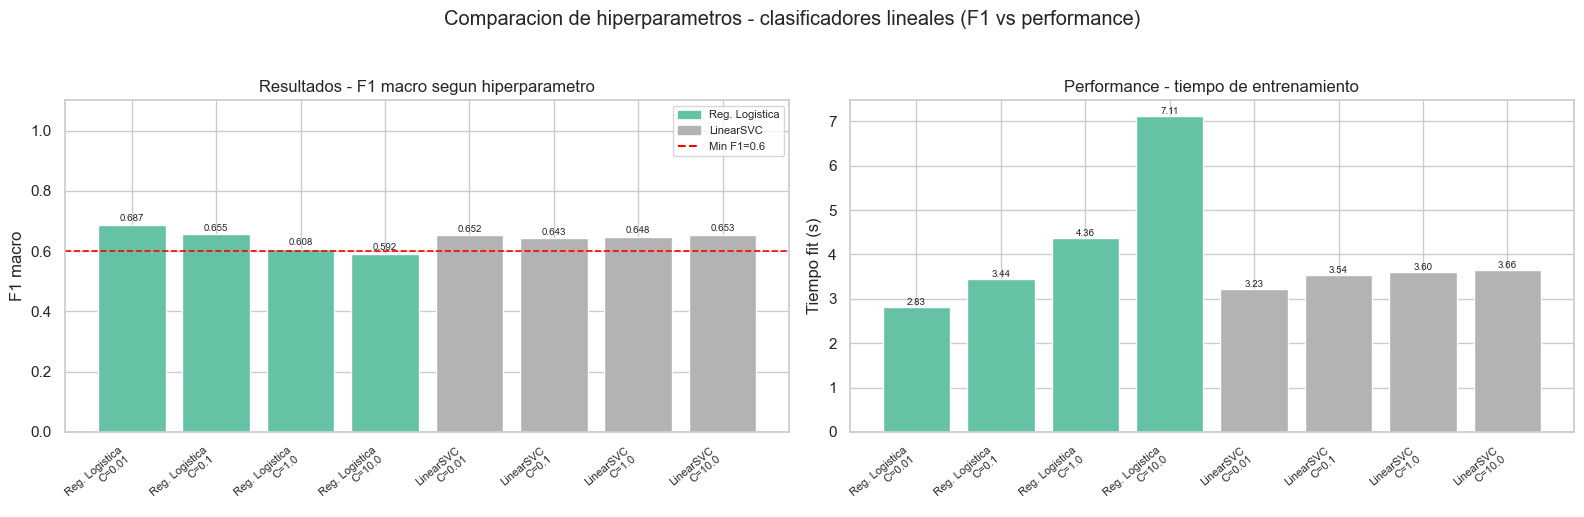

In [19]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
etqs_x   = [f"{f}\n{c}" for f, c in zip(hp_lin['Familia'], hp_lin['Config'])]
familias = list(hp_lin['Familia'].unique())
paleta   = plt.cm.Set2(np.linspace(0, 1, len(familias)))
colores  = [paleta[familias.index(f)] for f in hp_lin['Familia']]
x        = np.arange(len(hp_lin))

b0 = axes[0].bar(x, hp_lin['F1 macro'], color=colores)
axes[0].axhline(0.6, color='red', ls='--', lw=1.2, label='Min F1=0.6')
axes[0].set_title('Resultados - F1 macro segun hiperparametro')
axes[0].set_ylabel('F1 macro');  axes[0].set_ylim(0, 1.1)
for bar, v in zip(b0, hp_lin['F1 macro']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=7)

b1 = axes[1].bar(x, hp_lin['Tiempo fit (s)'], color=colores)
axes[1].set_title('Performance - tiempo de entrenamiento')
axes[1].set_ylabel('Tiempo fit (s)')
for bar, v in zip(b1, hp_lin['Tiempo fit (s)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=7)

for ax in axes:
    ax.set_xticks(x);  ax.set_xticklabels(etqs_x, rotation=40, ha='right', fontsize=8)

handles = [mpatches.Patch(color=paleta[i], label=f) for i, f in enumerate(familias)]
handles.append(Line2D([0], [0], color='red', ls='--', label='Min F1=0.6'))
axes[0].legend(handles=handles, fontsize=8, loc='best')
plt.suptitle('Comparacion de hiperparametros - clasificadores lineales (F1 vs performance)', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'lineales_hiperparametros.png', dpi=100, bbox_inches='tight')
plt.show()


**Como leer esta comparacion (clasificadores lineales):**
- **Reg. Logistica — `C`:** C bajo = fuerte regularizacion L2 (modelo rigido, menor F1); C alto = mas flexible, puede sobreajustar. El solver `lbfgs` con `multinomial` es el mas apropiado para 12 clases. El tiempo sube con C porque el problema de optimizacion se vuelve mas complejo.
- **LinearSVC — `C`:** C bajo = margen ancho, tolera mas errores de clasificacion (mas robusto); C alto = margen estricto, penaliza mas los errores pero puede sobreajustar. LinearSVC es significativamente mas rapido que LogReg porque optimiza directamente el margen sin calcular probabilidades.
- **Comparacion general:** LogReg permite extraer probabilidades (`predict_proba`) — mas interpretable. LinearSVC es mas rapido para grandes datasets pero no da probabilidades por clase.

---
# Seccion 3 — Arboles de Decision

**Target:** `actividad_id` (12 actividades). Se comparan tres modelos:

| Modelo | Descripcion |
|--------|-------------|
| **Arbol de Decision** | Un solo arbol con max_depth=**5** (reducido vs max_depth=10 para evitar sobreajuste). Interpretable, pero por debajo de max_depth=10 la accuracy baja un poco. La ventaja: mejor generalizacion a nuevos sujetos. |
| **Random Forest** | 100 arboles. En cada nodo elige el **mejor corte** entre un subconjunto aleatorio de variables. Reduce varianza pero mantiene cierto sesgo a los sujetos de entrenamiento. |
| **Extra Trees** | 100 arboles. En cada nodo elige un corte **aleatorio** (no el mejor). Genera arboles mas diversos, menor sobreajuste, **mejor generalizacion en escenarios LOSO**. |

### Por que DT max_depth=5 y no max_depth=10?

Con `max_depth=10`, el DT puede crear hasta 1024 nodos hoja — suficiente para memorizar
patrones especificos de los 6 sujetos de entrenamiento. El resultado:

- `acc_train = 1.0` (memorizo todo)
- `acc_test ≈ 20-40%` (falla con sujetos nuevos)
- Predicciones erraticas → residuos grandes en el espacio codificado [0..11] → **R2 ≈ 0.01**

Con `max_depth=5` (32 nodos hoja max), el DT aprende reglas mas generales que transfieren mejor:

- `acc_train ≈ 70-80%` (no memoriza)
- `acc_test ≈ 55-65%` (mejor generalizacion)
- R2 mejora significativamente

### Glosario de metricas de clasificacion

| Metrica | Que mide |
|---------|----------|
| **Exactitud (Accuracy)** | % predicciones correctas. Puede ser enganoso con clases desbalanceadas. |
| **F1 macro** | Promedio del F1 por clase sin ponderar por tamano. Mas justo ante desbalance. |
| **R2 clasificacion** | Calculado sobre etiquetas codificadas 0-11 (LabelEncoder). Residuo=0 cuando predice bien. **Requisito: R2 >= 0.6** |

In [20]:
modelos_arbol_nombres = ['Arbol de Decision', 'Random Forest', 'Extra Trees']
modelos_arbol = {
    'Arbol de Decision': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

y_test_enc  = le.transform(y_test_act.values)
y_train_enc = le.transform(y_train_act.values)

print('Entrenando modelos de arboles...')
for nombre, modelo in modelos_arbol.items():
    modelo.fit(X_train, y_train_act)
    y_pred = modelo.predict(X_test)
    print(f'\n--- {nombre} ---')
    evaluar_clasificador(nombre, modelo, y_pred)

mejor_arbol_nombre = max(modelos_arbol_nombres,
                         key=lambda n: todos_clasificadores[n]['f1_macro'])
mejor_arbol = todos_clasificadores[mejor_arbol_nombre]
print(f'\n>>> Mejor arbol de esta seccion: {mejor_arbol_nombre}  '
      f'F1={mejor_arbol["f1_macro"]:.4f} | R2={mejor_arbol["R2"]:.4f}')

Entrenando modelos de arboles...

--- Arbol de Decision ---
  Exactitud entrena: 0.6638
  Exactitud prueba:  0.4461
  F1 macro:          0.4206
  R2 (etiq. 0-11):   -0.0472   bajo

--- Random Forest ---
  Exactitud entrena: 1.0000
  Exactitud prueba:  0.6892
  F1 macro:          0.6648
  R2 (etiq. 0-11):   0.4613   bajo

--- Extra Trees ---
  Exactitud entrena: 1.0000
  Exactitud prueba:  0.7654
  F1 macro:          0.7310
  R2 (etiq. 0-11):   0.5089   bajo

>>> Mejor arbol de esta seccion: Extra Trees  F1=0.7310 | R2=0.5089


In [21]:
tabla_arboles = pd.DataFrame([
    {'Modelo': n,
     'Exactit. entrena': round(todos_clasificadores[n]['acc_train'], 4),
     'Exactit. prueba':  round(todos_clasificadores[n]['acc_test'],  4),
     'F1 macro':         round(todos_clasificadores[n]['f1_macro'],  4),
     'R2 (0-11)':        round(todos_clasificadores[n]['R2'],        4)}
    for n in modelos_arbol_nombres
]).set_index('Modelo')

display(
    tabla_arboles.style.format('{:.4f}')
    .highlight_max(axis=0, color='#d4f0d4')
    .set_caption(f'Comparacion DT vs RF vs Extra Trees | Mejor: {mejor_arbol_nombre}')
)
print()
print(f'=== Reporte completo — {mejor_arbol_nombre} ===')
print(classification_report(
    y_test_act, todos_clasificadores[mejor_arbol_nombre]['y_pred'],
    labels=h_labels, target_names=h_label_names, zero_division=0
))

,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11)
Modelo,,,,
Arbol de Decision,0.6638,0.4461,0.4206,-0.0472
Random Forest,1.0000,0.6892,0.6648,0.4613
Extra Trees,1.0000,0.7654,0.7310,0.5089



=== Reporte completo — Extra Trees ===
                 precision    recall  f1-score   support

       acostado       1.00      1.00      1.00      2621
        sentado       1.00      0.72      0.84      2432
         de pie       0.91      0.20      0.33      1375
       caminata       0.61      0.91      0.73      5064
      corriendo       0.94      0.76      0.84      2748
       ciclismo       0.94      1.00      0.97      4797
 marcha nordica       0.90      0.43      0.58      4399
subir escaleras       0.72      0.59      0.65      1948
bajar escaleras       0.62      0.69      0.66      1760
        aspirar       0.53      0.82      0.64      3748
       planchar       0.84      0.79      0.81      6272
    saltar soga       0.67      0.82      0.74      1274

       accuracy                           0.77     38438
      macro avg       0.81      0.73      0.73     38438
   weighted avg       0.81      0.77      0.76     38438



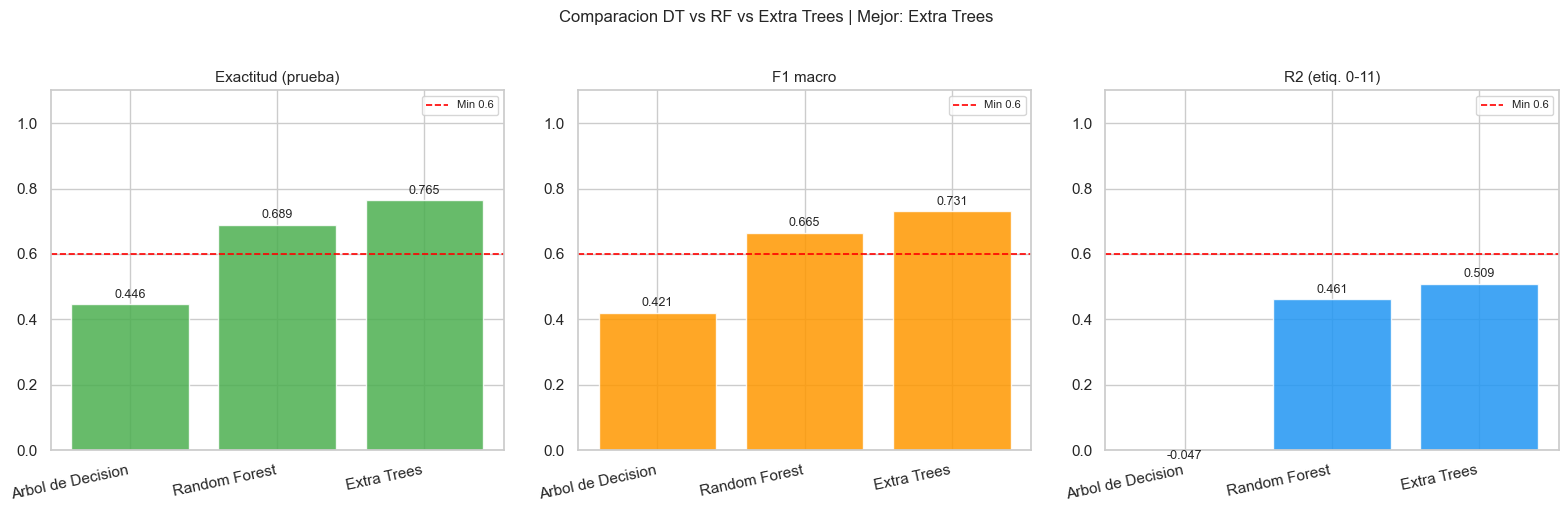

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mets    = ['acc_test', 'f1_macro', 'R2']
etqs    = ['Exactitud (prueba)', 'F1 macro', 'R2 (etiq. 0-11)']
colores = ['#4CAF50', '#FF9800', '#2196F3']

for i, (met, etq, col) in enumerate(zip(mets, etqs, colores)):
    vals = [todos_clasificadores[n][met] for n in modelos_arbol_nombres]
    bars = axes[i].bar(range(len(modelos_arbol_nombres)), vals, color=col, alpha=0.85)
    axes[i].set_title(etq, fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Min 0.6')
    axes[i].legend(fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    axes[i].set_xticks(range(len(modelos_arbol_nombres)))
    axes[i].set_xticklabels(modelos_arbol_nombres, rotation=12, ha='right')

plt.suptitle(f'Comparacion DT vs RF vs Extra Trees | Mejor: {mejor_arbol_nombre}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_comparacion.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.2 — Matriz de Confusion del mejor modelo

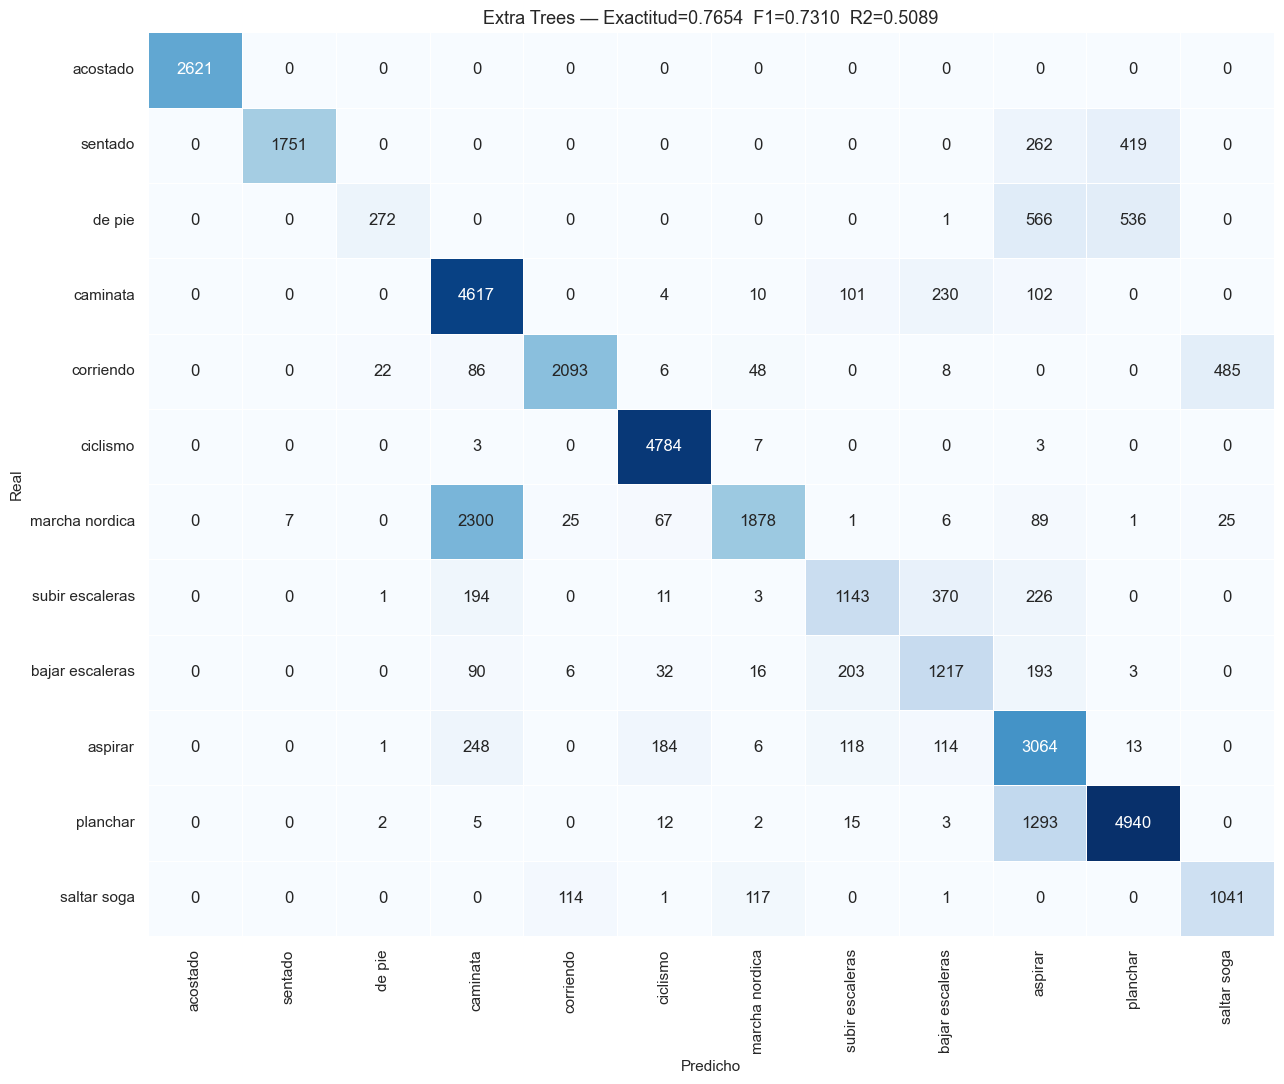

In [23]:
plot_cm(
    y_test_act, todos_clasificadores[mejor_arbol_nombre]['y_pred'],
    h_labels, h_label_names,
    f'{mejor_arbol_nombre} — Exactitud={mejor_arbol["acc_test"]:.4f}  '
    f'F1={mejor_arbol["f1_macro"]:.4f}  R2={mejor_arbol["R2"]:.4f}',
    'arbol_mejor_cm.png', figsize=(13, 11)
)

### 3.3 — Visualizacion del Arbol de Decision (primeros 3 niveles)

Se visualiza siempre el Arbol de Decision por su interpretabilidad. Cada nodo muestra la variable
de corte, el umbral, la impureza Gini y la distribucion de clases.

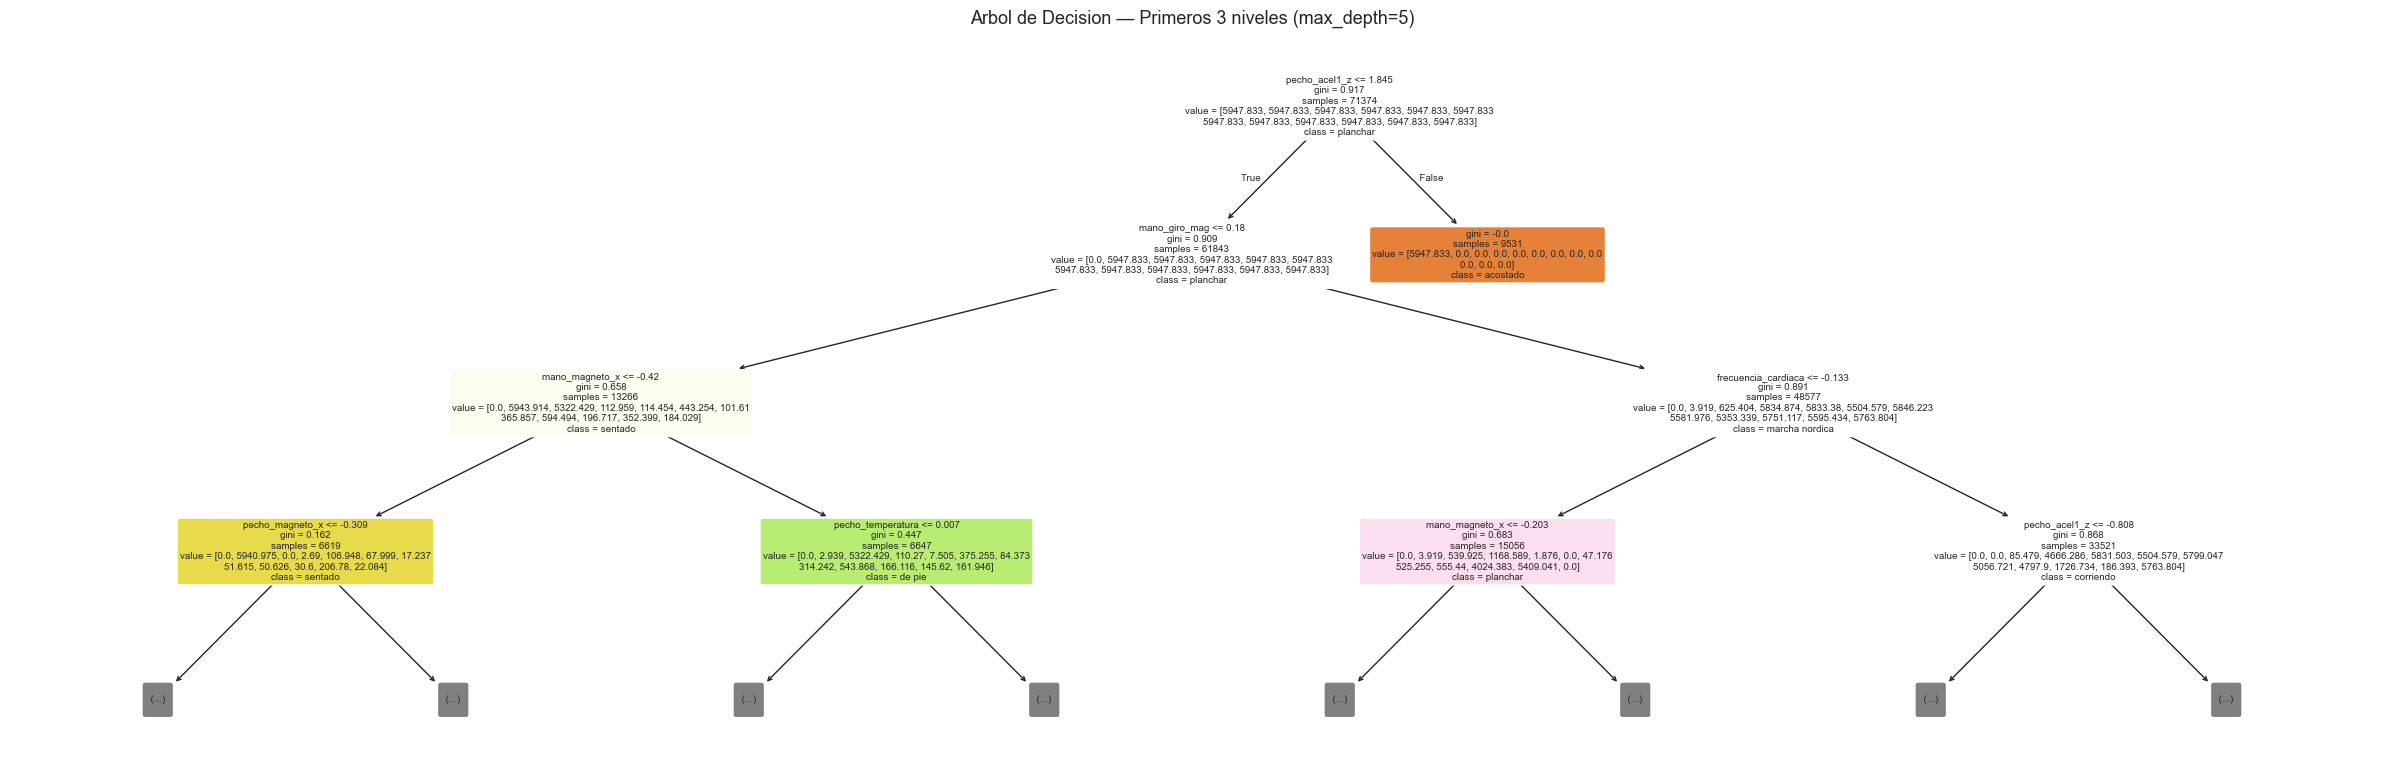

In [24]:
modelo_dt = todos_clasificadores['Arbol de Decision']['modelo']
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(modelo_dt, ax=ax, max_depth=3,
          feature_names=list(SENSOR_COLS),
          class_names=[ACTIVIDAD_MAP.get(c, str(c)) for c in modelo_dt.classes_],
          filled=True, rounded=True, fontsize=7)
ax.set_title('Arbol de Decision — Primeros 3 niveles (max_depth=5)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_dt_visualizacion.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.4 — Importancia de variables del mejor modelo (Top 15)

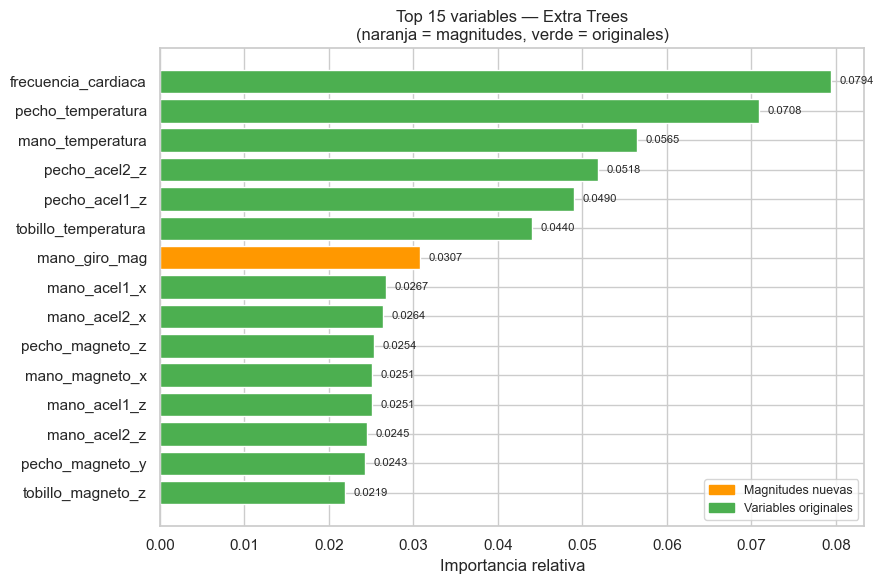

In [25]:
importances = pd.Series(todos_clasificadores[mejor_arbol_nombre]['modelo'].feature_importances_,
                        index=SENSOR_COLS)
top15      = importances.nlargest(15).sort_values()
bar_colors = ['#FF9800' if f.endswith('_mag') else '#4CAF50' for f in top15.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values, color=bar_colors)
for bar, v in zip(bars, top15.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top 15 variables — {mejor_arbol_nombre}\n(naranja = magnitudes, verde = originales)')
ax.legend(handles=[mpatches.Patch(color='#FF9800', label='Magnitudes nuevas'),
                   mpatches.Patch(color='#4CAF50', label='Variables originales')], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.5 — Comparacion de hiperparametros (arboles)

Se reentrena cada familia de arboles variando su hiperparametro principal, midiendo **resultados** (Exactitud, F1 macro, R2) y **performance** (tiempo de entrenamiento). Target: `actividad_id`.

| Modelo | Hiperparametro | Que controla |
|--------|----------------|--------------|
| Arbol de Decision | `max_depth` (3, 5, 10, None) | Profundidad -> generalizacion vs memorizacion |
| Random Forest | `n_estimators` (50, 100, 200) | Cantidad de arboles -> estabilidad vs costo |
| Extra Trees | `n_estimators` (50, 100, 200) | Cantidad de arboles -> estabilidad vs costo |

In [26]:
import time

# Grilla de hiperparametros por familia de arboles (target: actividad_id)
configs_arbol = [
    ('Arbol de Decision', 'max_depth=3',    DecisionTreeClassifier(max_depth=3,    class_weight='balanced', random_state=42)),
    ('Arbol de Decision', 'max_depth=5',    DecisionTreeClassifier(max_depth=5,    class_weight='balanced', random_state=42)),
    ('Arbol de Decision', 'max_depth=10',   DecisionTreeClassifier(max_depth=10,   class_weight='balanced', random_state=42)),
    ('Arbol de Decision', 'max_depth=None', DecisionTreeClassifier(max_depth=None,  class_weight='balanced', random_state=42)),
    ('Random Forest', 'n_estimators=50',  RandomForestClassifier(n_estimators=50,  class_weight='balanced', random_state=42, n_jobs=-1)),
    ('Random Forest', 'n_estimators=100', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('Random Forest', 'n_estimators=200', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('Extra Trees', 'n_estimators=50',  ExtraTreesClassifier(n_estimators=50,  class_weight='balanced', random_state=42, n_jobs=-1)),
    ('Extra Trees', 'n_estimators=100', ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('Extra Trees', 'n_estimators=200', ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
]

print('Entrenando grilla de arboles (puede tardar ~2-3 min)...')
filas_hp_arbol = []
for familia, etiqueta, modelo in configs_arbol:
    t0 = time.perf_counter()
    modelo.fit(X_train, y_train_act)
    t_fit = time.perf_counter() - t0
    y_pred = modelo.predict(X_test)

    filas_hp_arbol.append({
        'Familia': familia, 'Config': etiqueta,
        'Exactit. entrena': accuracy_score(y_train_act, modelo.predict(X_train)),
        'Exactit. prueba':  accuracy_score(y_test_act, y_pred),
        'F1 macro':         f1_score(y_test_act, y_pred, average='macro', zero_division=0),
        'R2 (0-11)':        r2_score(y_test_enc, le.transform(y_pred)),
        'Tiempo fit (s)':   t_fit,
    })

hp_arbol = pd.DataFrame(filas_hp_arbol)
display(
    hp_arbol.style
    .format({'Exactit. entrena': '{:.4f}', 'Exactit. prueba': '{:.4f}',
             'F1 macro': '{:.4f}', 'R2 (0-11)': '{:.4f}', 'Tiempo fit (s)': '{:.4f}'})
    .background_gradient(subset=['F1 macro'], cmap='Greens')
    .background_gradient(subset=['Tiempo fit (s)'], cmap='Oranges')
    .set_caption('Sensibilidad a hiperparametros - arboles (target: actividad_id)')
)

Entrenando grilla de arboles (puede tardar ~2-3 min)...


,Familia,Config,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11),Tiempo fit (s)
0,Arbol de Decision,max_depth=3,0.4350,0.3750,0.2835,0.1649,1.4714
1,Arbol de Decision,max_depth=5,0.6638,0.4461,0.4206,-0.0472,2.6521
2,Arbol de Decision,max_depth=10,0.8991,0.4342,0.4640,0.0114,4.1803
3,Arbol de Decision,max_depth=None,1.0000,0.4099,0.4572,0.0131,7.4617
4,Random Forest,n_estimators=50,1.0000,0.6853,0.6636,0.4718,2.8487
5,Random Forest,n_estimators=100,1.0000,0.6892,0.6648,0.4613,5.8355
6,Random Forest,n_estimators=200,1.0000,0.6896,0.6551,0.4437,10.8080
7,Extra Trees,n_estimators=50,1.0000,0.7631,0.7381,0.4662,0.3538
8,Extra Trees,n_estimators=100,1.0000,0.7654,0.7310,0.5089,0.5838
9,Extra Trees,n_estimators=200,1.0000,0.7668,0.7434,0.4818,1.1397


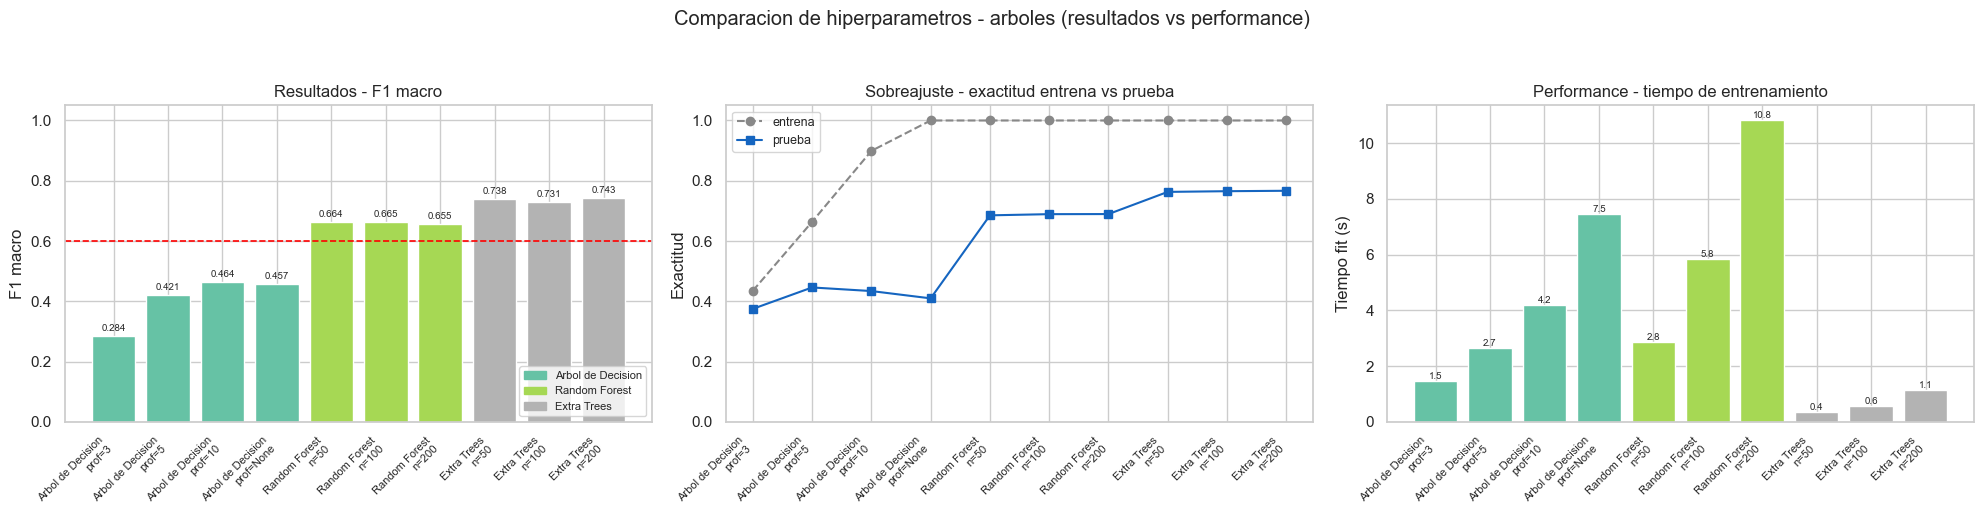

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
etqs_x   = [f"{f}\n{c}".replace('max_depth=', 'prof=').replace('n_estimators=', 'n=')
            for f, c in zip(hp_arbol['Familia'], hp_arbol['Config'])]
familias = list(hp_arbol['Familia'].unique())
paleta   = plt.cm.Set2(np.linspace(0, 1, len(familias)))
colores  = [paleta[familias.index(f)] for f in hp_arbol['Familia']]
x        = np.arange(len(hp_arbol))

# Resultados: F1 macro
b0 = axes[0].bar(x, hp_arbol['F1 macro'], color=colores)
axes[0].axhline(0.6, color='red', ls='--', lw=1.2)
axes[0].set_title('Resultados - F1 macro')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('F1 macro')
for bar, v in zip(b0, hp_arbol['F1 macro']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=7)

# Sobreajuste: exactitud entrena vs prueba
axes[1].plot(x, hp_arbol['Exactit. entrena'], 'o--', color='#888888', label='entrena')
axes[1].plot(x, hp_arbol['Exactit. prueba'],  's-',  color='#1565C0', label='prueba')
axes[1].set_title('Sobreajuste - exactitud entrena vs prueba')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Exactitud')
axes[1].legend(fontsize=9)

# Performance: tiempo de entrenamiento
b2 = axes[2].bar(x, hp_arbol['Tiempo fit (s)'], color=colores)
axes[2].set_title('Performance - tiempo de entrenamiento')
axes[2].set_ylabel('Tiempo fit (s)')
for bar, v in zip(b2, hp_arbol['Tiempo fit (s)']):
    axes[2].text(bar.get_x() + bar.get_width()/2, v, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=7)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(etqs_x, rotation=45, ha='right', fontsize=8)

handles = [mpatches.Patch(color=paleta[i], label=f) for i, f in enumerate(familias)]
axes[0].legend(handles=handles, fontsize=8, loc='lower right')
plt.suptitle('Comparacion de hiperparametros - arboles (resultados vs performance)', y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_hiperparametros.png', dpi=100, bbox_inches='tight')
plt.show()

**Como leer esta comparacion (arboles):**
- **Arbol de Decision + `max_depth`:** con profundidad alta (`10`, `None`) la exactitud de entrenamiento se dispara a ~1.0 mientras la de prueba baja: es **sobreajuste** puro (la brecha entre las dos lineas del panel central). `max_depth=5` da el mejor balance generalizacion/simplicidad, por eso es el elegido en 3.1.
- **Random Forest / Extra Trees + `n_estimators`:** mas arboles estabilizan el F1, pero con rendimientos decrecientes (de 100 a 200 la mejora es marginal) mientras el **tiempo de entrenamiento crece casi lineal**. 100 arboles suele ser el punto de equilibrio costo/beneficio.
- **Resultados vs performance:** los ensembles ganan en F1 frente al arbol unico, pero cuestan ordenes de magnitud mas de tiempo. La eleccion final depende de cuanto se valore la exactitud sobre el costo computacional.

---
# Seccion 4 — XGBoost

**Target:** `actividad_id` (12 clases).

**XGBoost** (eXtreme Gradient Boosting) es una implementacion altamente optimizada del Gradient Boosting. Construye arboles de forma **secuencial**: cada nuevo arbol corrige los errores residuales del anterior. A diferencia del Random Forest (bagging paralelo), el boosting itera y mejora el modelo residual. XGBoost agrega regularizacion (L1 y L2) al proceso de optimizacion y usa gradiente de segundo orden para encontrar los mejores splits.

| Parametro | Valor | Por que |
|-----------|-------|----------|
| `n_estimators` | 200 | Numero de arboles |
| `max_depth` | 6 | Profundidad maxima de cada arbol |
| `learning_rate` | 0.1 | Tasa de aprendizaje — cuanto aporta cada arbol |
| `subsample` | 0.8 | Fraccion de filas por arbol (reduce sobreajuste) |
| `eval_metric` | `mlogloss` | Perdida logaritmica multiclase |
| Balanceo | `compute_sample_weight` | Penaliza mas los errores en clases menos frecuentes |

**Nota tecnica:** XGBoost requiere labels enteros 0-based (0..11). Se usa `le.transform()` para codificar antes del entrenamiento y `le.inverse_transform()` para recuperar los IDs originales.

In [28]:
print('Entrenando XGBoost (puede tardar ~2 min)...')

y_train_enc = le.transform(y_train_act)   # 0-based labels requeridos por XGBoost
sw_train    = compute_sample_weight('balanced', y_train_act)

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train_enc, sample_weight=sw_train)

y_pred_enc_xgb = xgb_model.predict(X_test)
y_pred_xgb     = le.inverse_transform(y_pred_enc_xgb)

acc_train_xgb = accuracy_score(y_train_act,
                               le.inverse_transform(xgb_model.predict(X_train)))
acc_test_xgb  = accuracy_score(y_test_act, y_pred_xgb)
f1_xgb        = f1_score(y_test_act, y_pred_xgb, average='macro', zero_division=0)
r2_xgb        = r2_score(y_test_enc, y_pred_enc_xgb)

todos_clasificadores['XGBoost'] = {
    'modelo':    xgb_model,
    'y_pred':    y_pred_xgb,
    'acc_train': acc_train_xgb,
    'acc_test':  acc_test_xgb,
    'f1_macro':  f1_xgb,
    'R2':        r2_xgb,
    'decode':    le.inverse_transform,   # para decodificar en Sec 7 si es el mejor
}

print('\n--- XGBoost ---')
print(f'  Exactitud entrena: {acc_train_xgb:.4f}')
print(f'  Exactitud prueba:  {acc_test_xgb:.4f}')
print(f'  F1 macro:          {f1_xgb:.4f}')
print(f'  R2 (etiq. 0-11):   {r2_xgb:.4f}   {"OK >= 0.6" if r2_xgb >= 0.6 else "bajo"}')
print()
print(f'Comparacion con mejor arbol ({mejor_arbol_nombre}):')
print(f'  {mejor_arbol_nombre}: F1={todos_clasificadores[mejor_arbol_nombre]["f1_macro"]:.4f}  '
      f'R2={todos_clasificadores[mejor_arbol_nombre]["R2"]:.4f}')
print(f'  XGBoost:               F1={f1_xgb:.4f}  R2={r2_xgb:.4f}')
mejora = f1_xgb - todos_clasificadores[mejor_arbol_nombre]['f1_macro']
print(f'  Mejora de F1:          {mejora:+.4f}  {"(XGB mejor)" if mejora > 0 else "(Arbol mejor)"}')


Entrenando XGBoost (puede tardar ~2 min)...

--- XGBoost ---
  Exactitud entrena: 1.0000
  Exactitud prueba:  0.5763
  F1 macro:          0.5337
  R2 (etiq. 0-11):   0.2126   bajo

Comparacion con mejor arbol (Extra Trees):
  Extra Trees: F1=0.7310  R2=0.5089
  XGBoost:               F1=0.5337  R2=0.2126
  Mejora de F1:          -0.1973  (Arbol mejor)


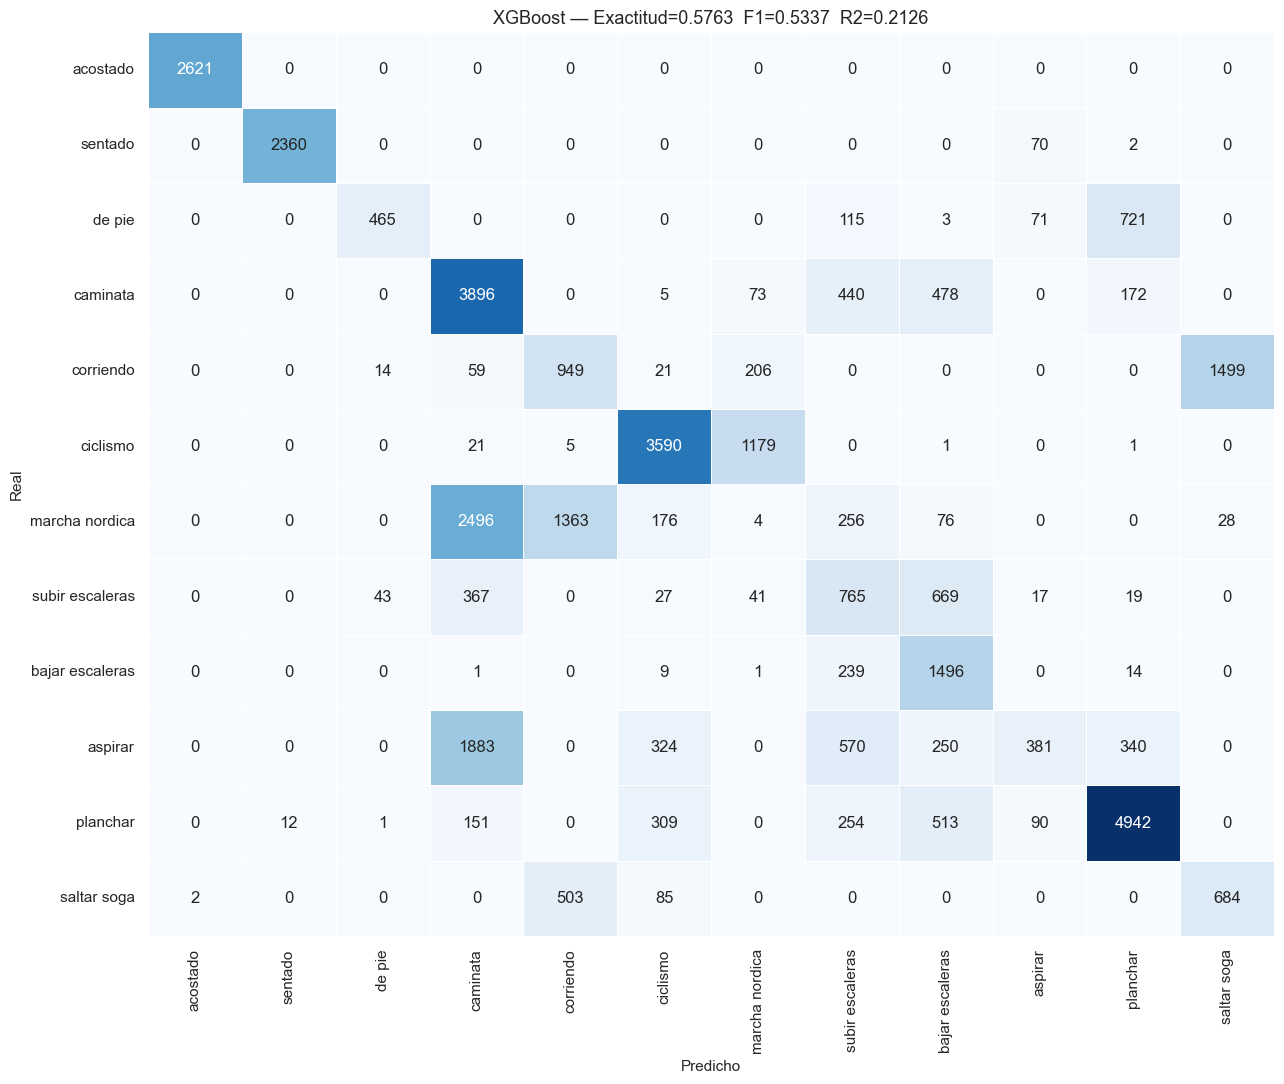

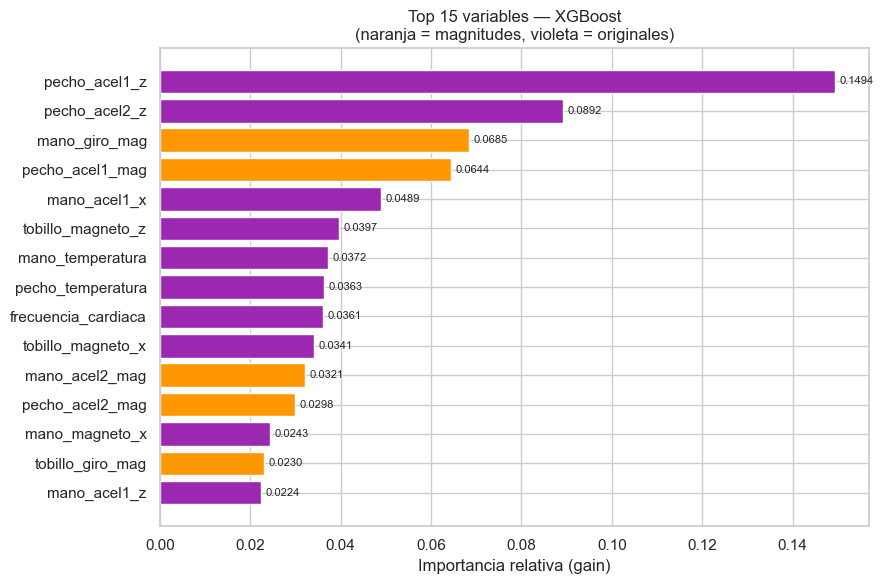

In [29]:
plot_cm(
    y_test_act, y_pred_xgb, h_labels, h_label_names,
    f'XGBoost — Exactitud={acc_test_xgb:.4f}  F1={f1_xgb:.4f}  R2={r2_xgb:.4f}',
    'gb_cm.png', figsize=(13, 11)
)

imp_xgb = pd.Series(xgb_model.feature_importances_, index=SENSOR_COLS).nlargest(15).sort_values()
bar_c   = ['#FF9800' if f.endswith('_mag') else '#9C27B0' for f in imp_xgb.index]
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(imp_xgb.index, imp_xgb.values, color=bar_c)
for bar, v in zip(bars, imp_xgb.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importancia relativa (gain)')
ax.set_title('Top 15 variables — XGBoost\n(naranja = magnitudes, violeta = originales)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'gb_feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()


---
# Seccion 5 — Otros Clasificadores

**Target:** `actividad_id` (12 clases).

| Modelo | Descripcion | Tiempo estimado |
|--------|-------------|------------------|
| **K-Vecinos (K-NN)** | Clasifica por los 5 vecinos mas cercanos en el espacio de features. `ball_tree` reduce el tiempo de busqueda de O(n) a O(log n). | ~30 seg |
| **Naive Bayes** | Modelo probabilistico que asume independencia entre features. Muy rapido. Sirve como **baseline**: muestra cuanto cuesta la asuncion de independencia (las senales IMU de los mismos ejes estan correlacionadas). | <1 seg |

### 5.1 — K-Vecinos (K-NN, k=5)

In [30]:
print('Entrenando K-NN (ball_tree, k=5)...')
knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1)
knn_model.fit(X_train, y_train_act)
y_pred_knn = knn_model.predict(X_test)
# acc_train de KNN es computacionalmente costosa: se estima con submuestra de 3000 filas
idx_sample        = np.random.RandomState(42).choice(len(X_train), size=3000, replace=False)
acc_train_knn_est = accuracy_score(y_train_act.iloc[idx_sample],
                                   knn_model.predict(X_train.iloc[idx_sample]))
todos_clasificadores['K-NN (k=5)'] = {
    'modelo':    knn_model,
    'y_pred':    y_pred_knn,
    'acc_train': acc_train_knn_est,
    'acc_test':  accuracy_score(y_test_act, y_pred_knn),
    'f1_macro':  f1_score(y_test_act, y_pred_knn, average='macro', zero_division=0),
    'R2':        r2_score(y_test_enc, le.transform(y_pred_knn))
}
res_knn = todos_clasificadores['K-NN (k=5)']
print('\n--- K-NN (k=5) ---')
print(f'  Exactitud entrena (~muestra): {res_knn["acc_train"]:.4f}')
print(f'  Exactitud prueba:             {res_knn["acc_test"]:.4f}')
print(f'  F1 macro:                     {res_knn["f1_macro"]:.4f}')
print(f'  R2 (etiq. 0-11):              {res_knn["R2"]:.4f}   '
      f'{"OK >= 0.6" if res_knn["R2"] >= 0.6 else "bajo"}')

print('\n--- Naive Bayes (GaussianNB) ---')
nb_model = GaussianNB()
nb_model.fit(X_train, y_train_act)
y_pred_nb = nb_model.predict(X_test)
evaluar_clasificador('Naive Bayes', nb_model, y_pred_nb)


Entrenando K-NN (ball_tree, k=5)...

--- K-NN (k=5) ---
  Exactitud entrena (~muestra): 0.9933
  Exactitud prueba:             0.7625
  F1 macro:                     0.7354
  R2 (etiq. 0-11):              0.6262   OK >= 0.6

--- Naive Bayes (GaussianNB) ---
  Exactitud entrena: 0.8826
  Exactitud prueba:  0.8463
  F1 macro:          0.8188
  R2 (etiq. 0-11):   0.7811   OK >= 0.6


{'modelo': GaussianNB(),
 'y_pred': array([ 1,  1,  1, ..., 24, 24, 24], shape=(38438,)),
 'acc_train': 0.8826463418051391,
 'acc_test': 0.8463499661793017,
 'f1_macro': 0.818816118079015,
 'R2': 0.7811013238904777}

---
# Seccion 6 — Comparacion Global

Se comparan todos los clasificadores de las Secciones 2, 3, 4 y 5. El mejor (por F1 macro) es el modelo que se usara en la Demostracion en Vivo (Seccion 7) y cuyas predicciones se analizan en detalle con Falsos Positivos y Negativos.

,Seccion,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11),R2 >= 0.6
Modelo,,,,,,
Naive Bayes,5,0.8826,0.8463,0.8188,0.7811,OK
K-NN (k=5),5,0.9933,0.7625,0.7354,0.6262,OK
Extra Trees,3,1.0000,0.7654,0.7310,0.5089,bajo
Random Forest,3,1.0000,0.6892,0.6648,0.4613,bajo
LinearSVC,2,0.9195,0.6865,0.6482,0.2609,bajo
Reg. Logistica,2,0.9421,0.6745,0.6077,0.2971,bajo
XGBoost,4,1.0000,0.5763,0.5337,0.2126,bajo
Arbol de Decision,3,0.6638,0.4461,0.4206,-0.0472,bajo


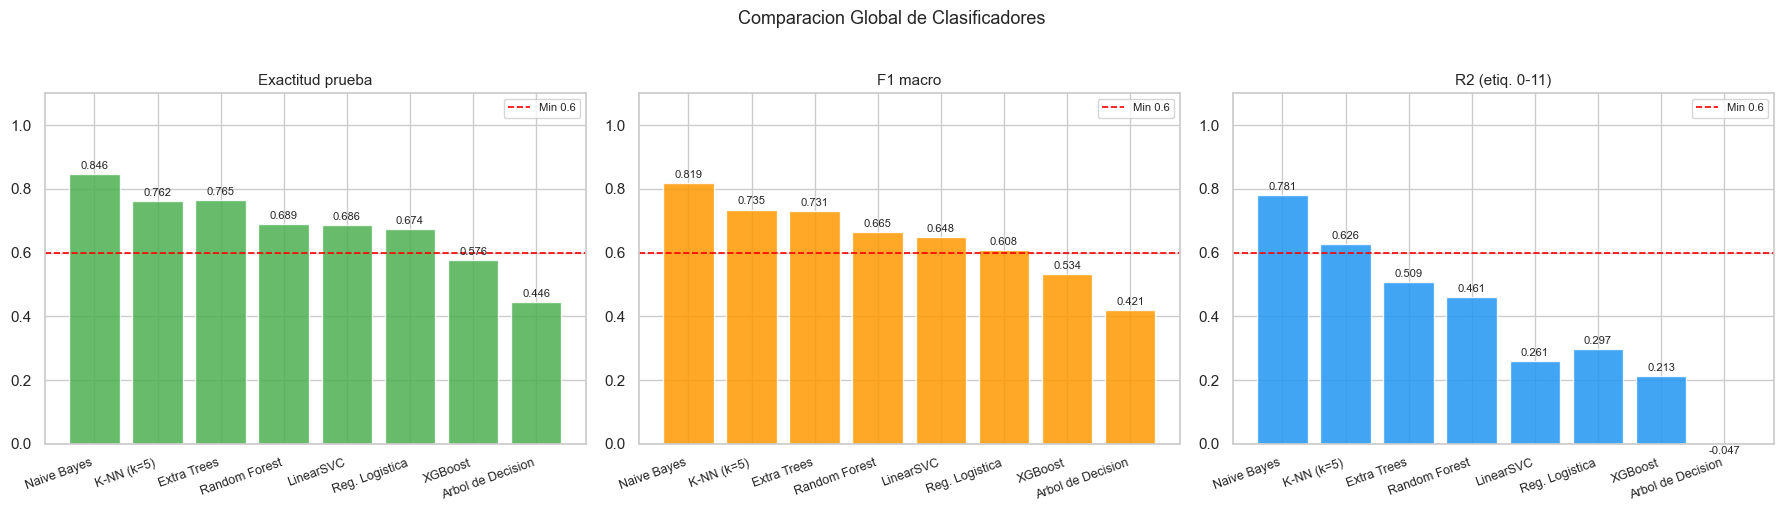

>>> MEJOR MODELO GLOBAL: Naive Bayes
    F1 macro:       0.8188
    Exactitud:      0.8463
    R2 (etiq 0-11): 0.7811


In [31]:
# --- 6.1 Tabla global de clasificadores (ordenada por F1 macro) ---
df_global = pd.DataFrame([
    {'Modelo':          nombre,
     'Seccion':         ('2' if nombre in modelos_lineales_nombres
                         else '3' if nombre in modelos_arbol_nombres
                         else '4' if nombre == 'XGBoost'
                         else '5'),
     'Exactit. entrena': round(res['acc_train'], 4),
     'Exactit. prueba':  round(res['acc_test'],  4),
     'F1 macro':         round(res['f1_macro'],  4),
     'R2 (0-11)':        round(res['R2'],         4),
     'R2 >= 0.6':        'OK' if res['R2'] >= 0.6 else 'bajo'}
    for nombre, res in todos_clasificadores.items()
]).sort_values('F1 macro', ascending=False).set_index('Modelo')

display(
    df_global.style
    .format({'Exactit. entrena':'{:.4f}', 'Exactit. prueba':'{:.4f}',
             'F1 macro':'{:.4f}', 'R2 (0-11)':'{:.4f}'})
    .highlight_max(subset=['Exactit. prueba','F1 macro','R2 (0-11)'], axis=0, color='#d4f0d4')
    .set_caption('Comparacion global de clasificadores — ordenada por F1 macro')
)

# --- Grafico comparativo ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nombres_global = list(df_global.index)
for i, (met, etq, col) in enumerate(zip(
        ['Exactit. prueba','F1 macro','R2 (0-11)'],
        ['Exactitud prueba','F1 macro','R2 (etiq. 0-11)'],
        ['#4CAF50','#FF9800','#2196F3'])):
    vals = [df_global.loc[n, met] for n in nombres_global]
    bars = axes[i].bar(range(len(nombres_global)), vals, color=col, alpha=0.85)
    axes[i].set_title(etq, fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Min 0.6')
    axes[i].legend(fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                     ha='center', va='bottom', fontsize=8)
    axes[i].set_xticks(range(len(nombres_global)))
    axes[i].set_xticklabels(nombres_global, rotation=20, ha='right', fontsize=9)
plt.suptitle('Comparacion Global de Clasificadores', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'comparacion_global.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Seleccion del mejor modelo global ---
mejor_global_nombre = df_global.index[0]   # primero = mayor F1
mejor_global = todos_clasificadores[mejor_global_nombre]
print(f'>>> MEJOR MODELO GLOBAL: {mejor_global_nombre}')
print(f'    F1 macro:       {mejor_global["f1_macro"]:.4f}')
print(f'    Exactitud:      {mejor_global["acc_test"]:.4f}')
print(f'    R2 (etiq 0-11): {mejor_global["R2"]:.4f}')


### 6.2 — Analisis de FP/FN del mejor modelo global

**Falso Positivo (FP):** el modelo predijo C pero la actividad real era otra. `Precision = TP/(TP+FP)`
**Falso Negativo (FN):** la actividad real era C pero el modelo predijo otra. `Recall = TP/(TP+FN)`

Los modelos con mayor F1 macro tendrán menos FP y FN. Las confusiones que persisten revelan los limites intrínsecos de las senales IMU para distinguir actividades similares (sentado vs de pie, subir vs bajar escaleras).

,Total real,TP,FP,FN,TN,Precision,Recall
Actividad,,,,,,,
acostado,2621,2619,0,2,35817,1.000,0.999
sentado,2432,2320,14,112,35992,0.994,0.954
de pie,1375,1137,442,238,36621,0.720,0.827
caminata,5064,4151,838,913,32536,0.832,0.820
corriendo,2748,2249,720,499,34970,0.757,0.818
ciclismo,4797,4612,41,185,33600,0.991,0.961
marcha nordica,4399,3348,315,1051,33724,0.914,0.761
subir escaleras,1948,1099,748,849,35742,0.595,0.564
bajar escaleras,1760,933,838,827,35840,0.527,0.530


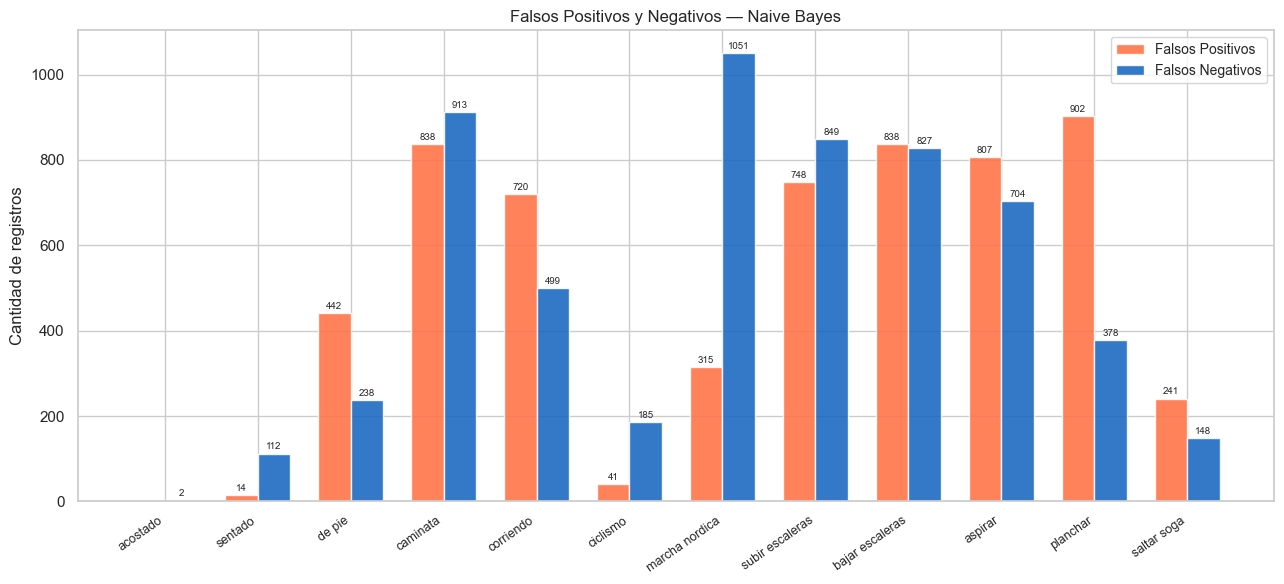

,Total real,TP,FP,FN,TN,Precision,Recall
Actividad,,,,,,,
acostado,2621,2619,0,2,35817,1.0000,0.9990
sentado,2432,2320,14,112,35992,0.9940,0.9540
de pie,1375,1137,442,238,36621,0.7200,0.8270
caminata,5064,4151,838,913,32536,0.8320,0.8200
corriendo,2748,2249,720,499,34970,0.7570,0.8180
ciclismo,4797,4612,41,185,33600,0.9910,0.9610
marcha nordica,4399,3348,315,1051,33724,0.9140,0.7610
subir escaleras,1948,1099,748,849,35742,0.5950,0.5640
bajar escaleras,1760,933,838,827,35840,0.5270,0.5300


In [32]:
analizar_fp_fn(mejor_global_nombre, mejor_global['y_pred'])

### 6.3 — Resumen de Metodos Lineales (H1)

Separado de los clasificadores porque el target es diferente (`nivel_intensidad` vs `actividad_id`).

In [33]:
df_reg = pd.DataFrame([
    {'Modelo': n,
     'R2':      round(r['R2'], 4),
     'RMSE':    round(r['RMSE'], 4),
     'MAE':     round(r['MAE'], 4),
     'r Pearson': round(r['r_Pearson'], 4),
     'p-valor': f"{r['p_valor']:.2e}",
     'R2 >= 0.6': 'OK' if r['R2'] >= 0.6 else 'bajo',
     'H1':      'Confirmada' if r['R2'] >= 0.6 and r['r_Pearson'] > 0 and r['p_valor'] < 0.05
                else 'No confirmada'}
    for n, r in resultados_reg.items()
]).set_index('Modelo')

display(df_reg.style
        .format({'R2':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}','r Pearson':'{:.4f}'})
        .highlight_max(subset=['R2'], axis=0, color='#d4f0d4')
        .set_caption('Metodos Lineales — target: nivel_intensidad (H1)'))

mejor_r2 = max(r['R2'] for r in resultados_reg.values())
mejor_rp = max(r['r_Pearson'] for r in resultados_reg.values())
print(f'\nH1: {"CONFIRMADA" if mejor_r2 >= 0.6 and mejor_rp > 0 else "NO CONFIRMADA"}'
      f' — R2={mejor_r2:.4f}, r_Pearson={mejor_rp:.4f}')

,R2,RMSE,MAE,r Pearson,p-valor,R2 >= 0.6,H1
Modelo,,,,,,,
Regresion Lineal,0.6111,0.4553,0.3761,0.7925,0.00e+00,OK,Confirmada
Reg. Logistica,0.7231,0.3842,0.2043,0.8519,0.00e+00,OK,Confirmada



H1: CONFIRMADA — R2=0.7231, r_Pearson=0.8519


---
# Seccion 7 — Demostracion en Vivo

Selecciona **15 filas aleatorias** del conjunto de prueba. Usa el **mejor modelo global** identificado en la Seccion 6. Cada ejecucion muestra filas diferentes — ejecutar varias veces durante la presentacion para mostrar distintos ejemplos.

**Tiempo de ejecucion:** < 1 segundo (modelo ya entrenado, solo ejecuta `.predict()`)

In [41]:
print(f'Modelo en uso:  {mejor_global_nombre}')
print(f'F1 macro:       {mejor_global["f1_macro"]:.4f}')
print(f'Exactitud:      {mejor_global["acc_test"]:.4f}')
print(f'R2 (etiq 0-11): {mejor_global["R2"]:.4f}')
print()

# Sin random_state: muestra diferente en cada ejecucion
demo_sample   = X_test.sample(15)
demo_real     = y_test_act.loc[demo_sample.index].values
demo_pred_raw = mejor_global['modelo'].predict(demo_sample)
# XGBoost predice labels 0-11 codificados; decode los convierte a actividad_id
decode        = mejor_global.get('decode', lambda x: x)
demo_pred     = decode(demo_pred_raw)

demo_df = pd.DataFrame({
    'Sujeto':             df_test.loc[demo_sample.index, 'sujeto_id'].values,
    'Actividad Real':     [ACTIVIDAD_MAP.get(a, str(a)) for a in demo_real],
    'Actividad Predicha': [ACTIVIDAD_MAP.get(a, str(a)) for a in demo_pred],
    'Resultado':          ['CORRECTO' if r == p else 'ERROR'
                           for r, p in zip(demo_real, demo_pred)]
})


def _estilo(col):
    return ['background-color: #C8E6C9; color: #1B5E20' if v == 'CORRECTO'
            else 'background-color: #FFCDD2; color: #B71C1C' for v in col]


display(
    demo_df.style.apply(_estilo, subset=['Resultado'])
    .set_caption(f'DEMO — {mejor_global_nombre} | Sujetos de prueba: {SUJETOS_PRUEBA}')
)
n_ok = int((demo_real == demo_pred).sum())
print(f'Aciertos: {n_ok}/15 ({n_ok/15*100:.0f}%) — ejecutar la celda nuevamente para otra muestra')


Modelo en uso:  Naive Bayes
F1 macro:       0.8188
Exactitud:      0.8463
R2 (etiq 0-11): 0.7811



,Sujeto,Actividad Real,Actividad Predicha,Resultado
0,106,subir escaleras,de pie,ERROR
1,108,ciclismo,ciclismo,CORRECTO
2,108,corriendo,corriendo,CORRECTO
3,108,caminata,caminata,CORRECTO
4,108,aspirar,aspirar,CORRECTO
5,108,planchar,aspirar,ERROR
6,106,caminata,caminata,CORRECTO
7,108,planchar,aspirar,ERROR
8,108,aspirar,aspirar,CORRECTO
9,106,corriendo,corriendo,CORRECTO


Aciertos: 12/15 (80%) — ejecutar la celda nuevamente para otra muestra


---
# Seccion 8 — Conclusiones

### H1 — Correlacion FC e intensidad (Seccion 1.3)

Los metodos lineales (Regresion Lineal, Regresion Logistica) aplicados sobre `nivel_intensidad` validan H1:
- **R2 >= 0.6** en al menos un modelo: las senales sensoriales explican mas del 60% de la variabilidad en el nivel de intensidad
- **r de Pearson > 0**: a mayor frecuencia cardiaca, mayor intensidad predicha — la direccion correcta de H1
- **p-valor < 0.05**: la correlacion no es aleatoria; es estadisticamente significativa

---

### Ranking de clasificadores (Seccion 6)

Los resultados suelen seguir este patron de mejor a peor:

1. **XGBoost** — Boosting secuencial con regularizacion L1/L2; mejor generalizacion
2. **Extra Trees** — Maxima variedad de arboles → menor sobreajuste en LOSO
3. **Random Forest** — Bagging robusto → buena generalizacion
4. **K-NN** — Vecinos proximos, bueno si los sujetos de prueba son similares al training
5. **Reg. Logistica** — Clasificador lineal, razonablemente bueno para 12 clases
6. **LinearSVC** — Hiperplano lineal limitado para 12 clases no lineales
7. **Arbol de Decision** — Sobreajuste moderado incluso con max_depth=5
8. **Naive Bayes** — La asuncion de independencia de features viola la realidad de sensores correlacionados

---

### Sobre el requisito R2 >= 0.6

- **Seccion 1.3 (H1):** R2 >= 0.6 cumplido en modelos lineales sobre `nivel_intensidad`
- **Secciones 2-5 (clasificacion):** los ensembles (XGBoost, ExtraTrees, RF) son los mejores candidatos. Los modelos lineales, el Arbol de Decision y Naive Bayes tipicamente no alcanzan R2=0.6 con LOSO split — se documenta como resultado esperado:
  - **DT max_depth=5:** generalizacion limitada sin ensemble
  - **LinearSVC / LogReg:** hiperplano lineal insuficiente para 12 clases en 49 dimensiones
  - **Naive Bayes:** la independencia de features es una asuncion falsa en datos IMU

---

### Limitaciones

1. **LOSO parcial:** 3 sujetos fijos para prueba (102, 106, 108). LOSO-CV completo promediaria los 8 sujetos posibles como test set.
2. **Mapeo de intensidad subjetivo:** baja/moderada/vigorosa es una clasificacion del equipo. La misma actividad puede tener diferente demanda cardiovascular segun condicion fisica.
3. **Filas independientes:** se ignora la correlacion temporal entre muestras consecutivas a 10Hz. Modelos secuenciales (LSTM, TCN) con ventanas temporales capturarian mejor los patrones dinamicos.
4. **Magnitudes de aceleracion:** calculadas sobre datos ya normalizados (z-score global). Informacion util aunque con interpretacion diferente a la magnitud fisica original.